# Red Neuronal con Fashion MNIST - Clasificación Multiclase

Este cuaderno implementa diferentes arquitecturas de redes neuronales para clasificar imágenes del dataset Fashion MNIST.

## Dataset Fashion MNIST
- 70,000 imágenes en escala de grises de 28x28 píxeles
- 10 clases de prendas de vestir:
  - 0: T-shirt/top
  - 1: Trouser
  - 2: Pullover
  - 3: Dress
  - 4: Coat
  - 5: Sandal
  - 6: Shirt
  - 7: Sneaker
  - 8: Bag
  - 9: Ankle boot

Cargando dataset Fashion MNIST...

Forma de los datos de entrenamiento: (60000, 28, 28)
Forma de los datos de test: (10000, 28, 28)
Forma de las etiquetas de entrenamiento: (60000,)
Forma de las etiquetas de test: (10000,)

Rango de valores de píxeles: [0, 255]
Número de clases: 10

Distribución de clases en el conjunto de entrenamiento:
  0 (T-shirt/top): 6000 imágenes (10.00%)
  1 (Trouser): 6000 imágenes (10.00%)
  2 (Pullover): 6000 imágenes (10.00%)
  3 (Dress): 6000 imágenes (10.00%)
  4 (Coat): 6000 imágenes (10.00%)
  5 (Sandal): 6000 imágenes (10.00%)
  6 (Shirt): 6000 imágenes (10.00%)
  7 (Sneaker): 6000 imágenes (10.00%)
  8 (Bag): 6000 imágenes (10.00%)
  9 (Ankle boot): 6000 imágenes (10.00%)


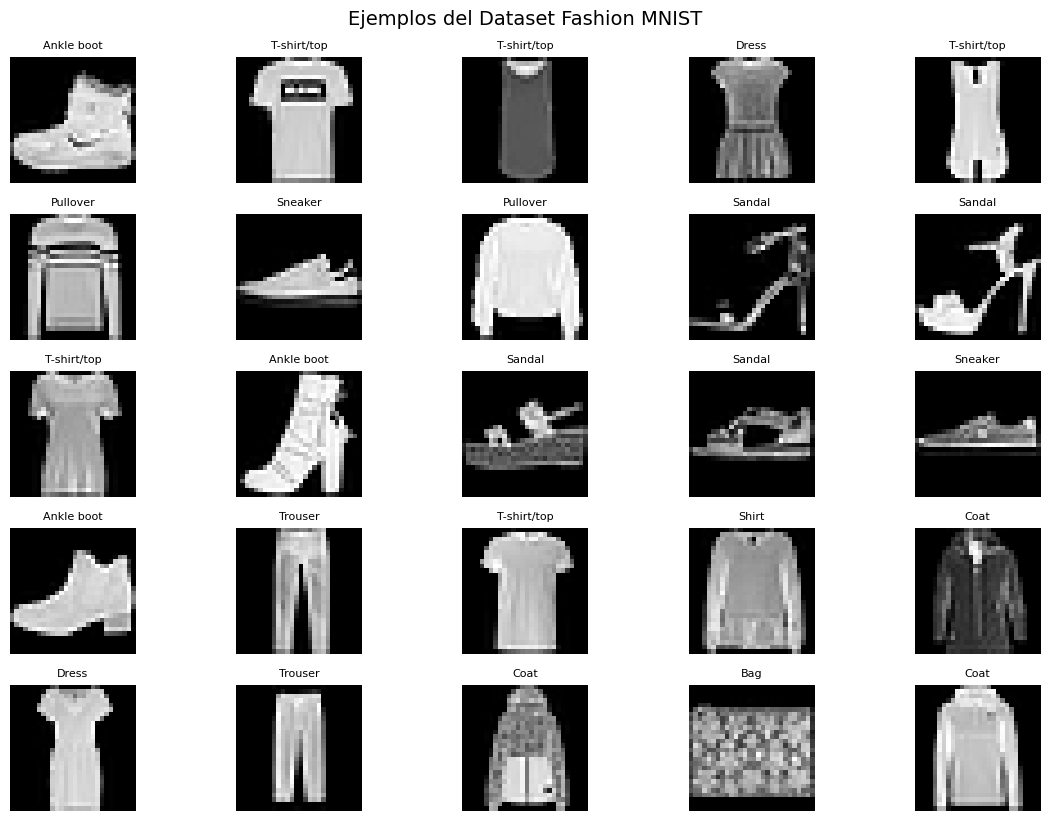


INFORMACIÓN DEL DATASET
Total de imágenes de entrenamiento: 60000
Total de imágenes de test: 10000
Dimensiones de cada imagen: 28x28 píxeles
Total de características por imagen: 784 píxeles
Número de clases: 10

NOTA: Fashion MNIST es un dataset de clasificación multiclase con 10 categorías.
Las imágenes están en escala de grises (0-255).


In [17]:
# Importaciones necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout
from keras.optimizers import Adam, SGD, RMSprop
from keras.callbacks import EarlyStopping

# Configuración
np.random.seed(42)
tf.random.set_seed(42)

# Cargar el dataset Fashion MNIST
print("Cargando dataset Fashion MNIST...")
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

# Nombres de las clases
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"\nForma de los datos de entrenamiento: {X_train_full.shape}")
print(f"Forma de los datos de test: {X_test.shape}")
print(f"Forma de las etiquetas de entrenamiento: {y_train_full.shape}")
print(f"Forma de las etiquetas de test: {y_test.shape}")

print(f"\nRango de valores de píxeles: [{X_train_full.min()}, {X_train_full.max()}]")
print(f"Número de clases: {len(class_names)}")

# Mostrar distribución de clases
print("\nDistribución de clases en el conjunto de entrenamiento:")
unique, counts = np.unique(y_train_full, return_counts=True)
for i, (clase, count) in enumerate(zip(unique, counts)):
    print(f"  {clase} ({class_names[clase]}): {count} imágenes ({count/len(y_train_full)*100:.2f}%)")

# Visualizar algunas imágenes de ejemplo
plt.figure(figsize=(12, 8))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_train_full[i], cmap='gray')
    plt.title(class_names[y_train_full[i]], fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.suptitle('Ejemplos del Dataset Fashion MNIST', y=1.02, fontsize=14)
plt.show()

print("\n" + "="*80)
print("INFORMACIÓN DEL DATASET")
print("="*80)
print(f"Total de imágenes de entrenamiento: {len(X_train_full)}")
print(f"Total de imágenes de test: {len(X_test)}")
print(f"Dimensiones de cada imagen: 28x28 píxeles")
print(f"Total de características por imagen: {28*28} píxeles")
print(f"Número de clases: {len(class_names)}")
print("\nNOTA: Fashion MNIST es un dataset de clasificación multiclase con 10 categorías.")
print("Las imágenes están en escala de grises (0-255).")

MODELO 1: Red Neuronal Simple
Configuración: 1 característica de entrada (promedio de píxeles)
Arquitectura: Entrada(1) -> Capa Oculta(32, relu) -> Salida(10, softmax)

Forma de X_avg: (60000, 1)
Forma de X_test_avg: (10000, 1)

Separando datos: 60% train, 20% validation, 20% test...
Tamaño conjunto de entrenamiento: 36000
Tamaño conjunto de validación: 12000
Tamaño conjunto de test: 12000

Rango después de normalización: [0.00, 1.00]

Resumen del modelo:


c:\Users\ampr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 32)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 394 (1.54 KB)

 Trainable params: 394 (1.54 KB)

 Non-trainable params: 0 (0.00 B)


Entrenando modelo...
Epoch 1/50
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.1666 - loss: 2.1746 - val_accuracy: 0.2183 - val_loss: 2.0532
Epoch 2/50
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 1s 984us/step - accuracy: 0.2272 - loss: 2.0212 - val_accuracy: 0.2476 - val_loss: 1.9990
Epoch 3/50
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 1s 966us/step - accuracy: 0.2450 - loss: 1.9954 - val_accuracy: 0.2597 - val_loss: 1.9858
Epoch 4/50
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2508 - loss: 1.9860 - val_accuracy: 0.2630 - val_loss: 1.9788
Epoch 5/50
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 1s 960us/step - accuracy: 0.2548 - loss: 1.9803 - val_accuracy: 0.2654 - val_loss: 1.9742
Epoch 6/50
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 1s 984us/step - accuracy: 0.2562 - loss: 1.9761 - val_accuracy: 0.2668 - val_loss: 1.9706
Epoch 7/50
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 1s 966us/step - accuracy: 0.2588 - loss: 1.9726 - val_accuracy: 0.2688 - val_loss: 1.9675
Epoch 8/50
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 1s 977us/step - 

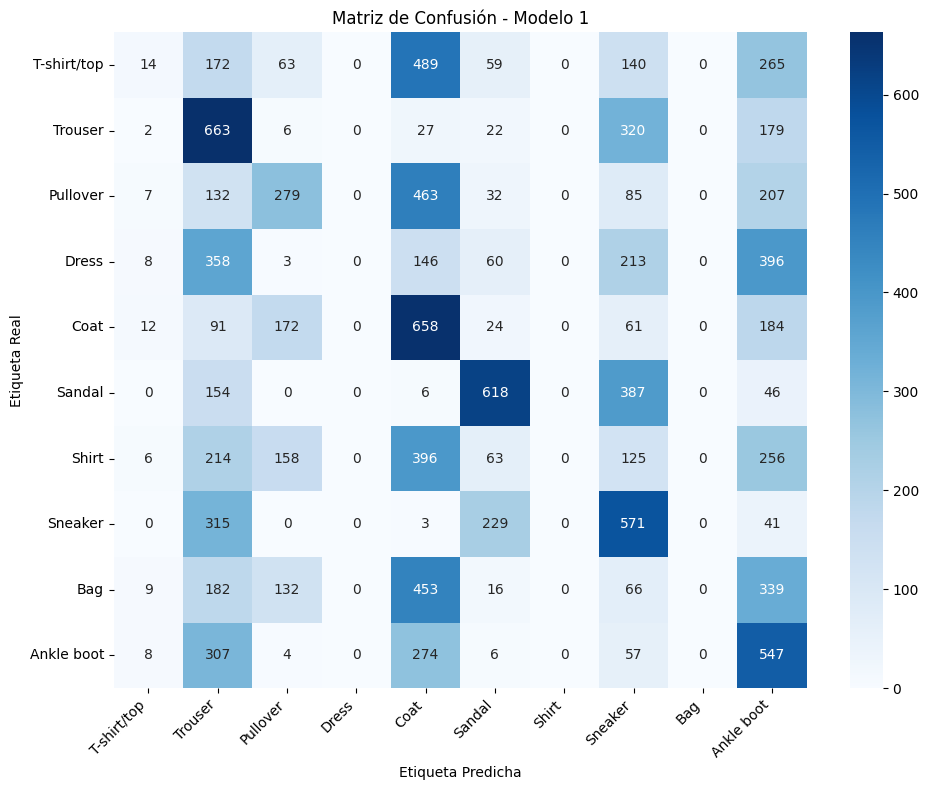

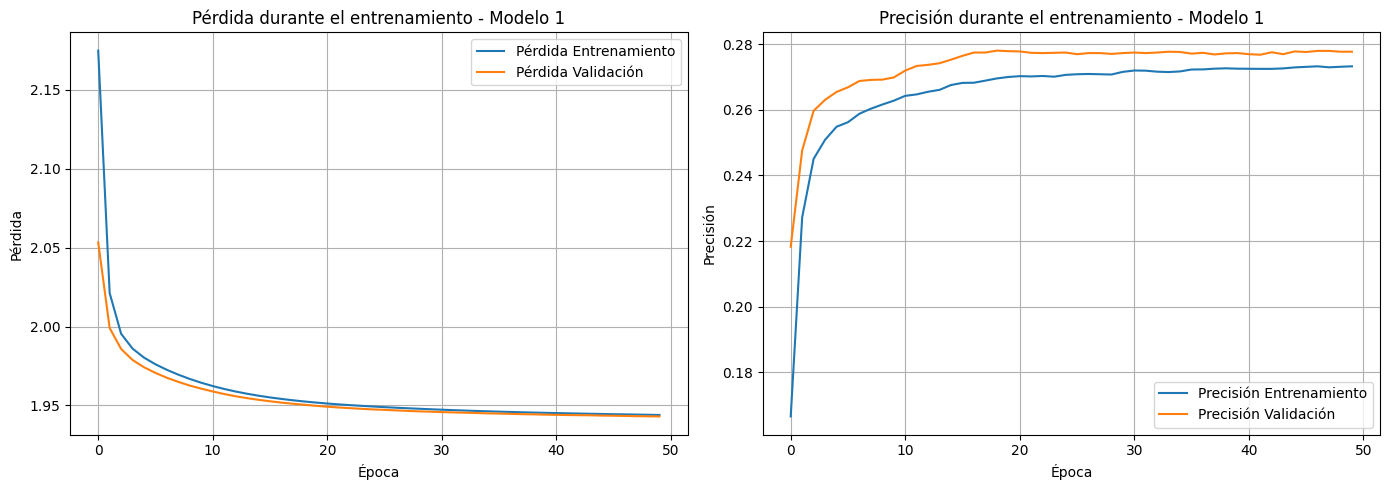


MODELO 1 completado.


In [18]:
# MODELO 1: Red Neuronal Simple (1 característica simulada - promedio de píxeles)
print("="*80)
print("MODELO 1: Red Neuronal Simple")
print("="*80)
print("Configuración: 1 característica de entrada (promedio de píxeles)")
print("Arquitectura: Entrada(1) -> Capa Oculta(32, relu) -> Salida(10, softmax)")
print("="*80 + "\n")

# Crear característica: promedio de píxeles de cada imagen
X_avg = X_train_full.reshape(len(X_train_full), -1).mean(axis=1).reshape(-1, 1)
X_test_avg = X_test.reshape(len(X_test), -1).mean(axis=1).reshape(-1, 1)

# Convertir etiquetas a one-hot encoding
y_train_cat = keras.utils.to_categorical(y_train_full, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)

print(f"Forma de X_avg: {X_avg.shape}")
print(f"Forma de X_test_avg: {X_test_avg.shape}")

# División: 60% train, 20% validation, 20% test
print("\nSeparando datos: 60% train, 20% validation, 20% test...")
X_temp, X_test_1, y_temp, y_test_1 = train_test_split(X_avg, y_train_cat, test_size=0.20, random_state=42, shuffle=True)
X_train_1, X_val_1, y_train_1, y_val_1 = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, shuffle=True)

print(f"Tamaño conjunto de entrenamiento: {len(X_train_1)}")
print(f"Tamaño conjunto de validación: {len(X_val_1)}")
print(f"Tamaño conjunto de test: {len(X_test_1)}")

# Normalización
scaler_1 = MinMaxScaler()
X_train_1_scaled = scaler_1.fit_transform(X_train_1)
X_val_1_scaled = scaler_1.transform(X_val_1)
X_test_1_scaled = scaler_1.transform(X_test_1)

print(f"\nRango después de normalización: [{X_train_1_scaled.min():.2f}, {X_train_1_scaled.max():.2f}]")

# Construcción del modelo
model_1 = Sequential([
    Dense(32, activation='relu', input_shape=(1,), name='hidden_layer'),
    Dense(10, activation='softmax', name='output_layer')
])

model_1.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

print("\nResumen del modelo:")
model_1.summary()

# Entrenamiento
print("\nEntrenando modelo...")
history_1 = model_1.fit(X_train_1_scaled, y_train_1,
                        epochs=50,
                        batch_size=32,
                        validation_data=(X_val_1_scaled, y_val_1),
                        verbose=1)

# Evaluación
print("\n--- Evaluación en conjunto de test ---")
test_loss_1, test_accuracy_1 = model_1.evaluate(X_test_1_scaled, y_test_1, verbose=0)
print(f"Pérdida en test: {test_loss_1:.4f}")
print(f"Precisión en test: {test_accuracy_1:.4f}")

# Predicciones
y_pred_1 = model_1.predict(X_test_1_scaled, verbose=0)
y_pred_classes_1 = np.argmax(y_pred_1, axis=1)
y_test_classes_1 = np.argmax(y_test_1, axis=1)

# Métricas detalladas
print("\n--- Métricas Detalladas ---")
print(f"Accuracy: {accuracy_score(y_test_classes_1, y_pred_classes_1):.4f}")
print(f"Precision (macro): {precision_score(y_test_classes_1, y_pred_classes_1, average='macro', zero_division=0):.4f}")
print(f"Recall (macro): {recall_score(y_test_classes_1, y_pred_classes_1, average='macro', zero_division=0):.4f}")
print(f"F1-Score (macro): {f1_score(y_test_classes_1, y_pred_classes_1, average='macro', zero_division=0):.4f}")

# Matriz de confusión
cm_1 = confusion_matrix(y_test_classes_1, y_pred_classes_1)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_1, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión - Modelo 1')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Gráfico de pérdida y precisión
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_1.history['loss'], label='Pérdida Entrenamiento')
ax1.plot(history_1.history['val_loss'], label='Pérdida Validación')
ax1.set_title('Pérdida durante el entrenamiento - Modelo 1')
ax1.set_xlabel('Época')
ax1.set_ylabel('Pérdida')
ax1.legend()
ax1.grid(True)

ax2.plot(history_1.history['accuracy'], label='Precisión Entrenamiento')
ax2.plot(history_1.history['val_accuracy'], label='Precisión Validación')
ax2.set_title('Precisión durante el entrenamiento - Modelo 1')
ax2.set_xlabel('Época')
ax2.set_ylabel('Precisión')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\nMODELO 1 completado.")

MODELO 2: Red Neuronal con todas las características (píxeles)
Configuración: 784 características de entrada (28x28 píxeles aplanados)
Arquitectura: Entrada(784) -> Dense(128, relu) -> Dense(64, relu) -> Salida(10, softmax)

Forma de X_flat: (60000, 784)
Forma de X_test_flat: (10000, 784)

Separando datos: 60% train, 20% validation, 20% test...
Tamaño conjunto de entrenamiento: 36000
Tamaño conjunto de validación: 12000
Tamaño conjunto de test: 12000

Normalizando píxeles a rango [0, 1]...
Rango después de normalización: [0.00, 1.00]

Resumen del modelo:


c:\Users\ampr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


Entrenando modelo...
Epoch 1/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7866 - loss: 0.6145 - val_accuracy: 0.8498 - val_loss: 0.4365
Epoch 2/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8497 - loss: 0.4271 - val_accuracy: 0.8643 - val_loss: 0.3910
Epoch 3/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8649 - loss: 0.3793 - val_accuracy: 0.8719 - val_loss: 0.3670
Epoch 4/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8750 - loss: 0.3498 - val_accuracy: 0.8772 - val_loss: 0.3495
Epoch 5/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8812 - loss: 0.3267 - val_accuracy: 0.8810 - val_loss: 0.3356
Epoch 6/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8874 - loss: 0.3101 - val_accuracy: 0.8822 - val_loss: 0.3321
Epoch 7/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8925 - loss: 0.2937 - val_accuracy: 0.8835 - val_loss: 0.3281
Epoch 8/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8973 - loss: 0.2

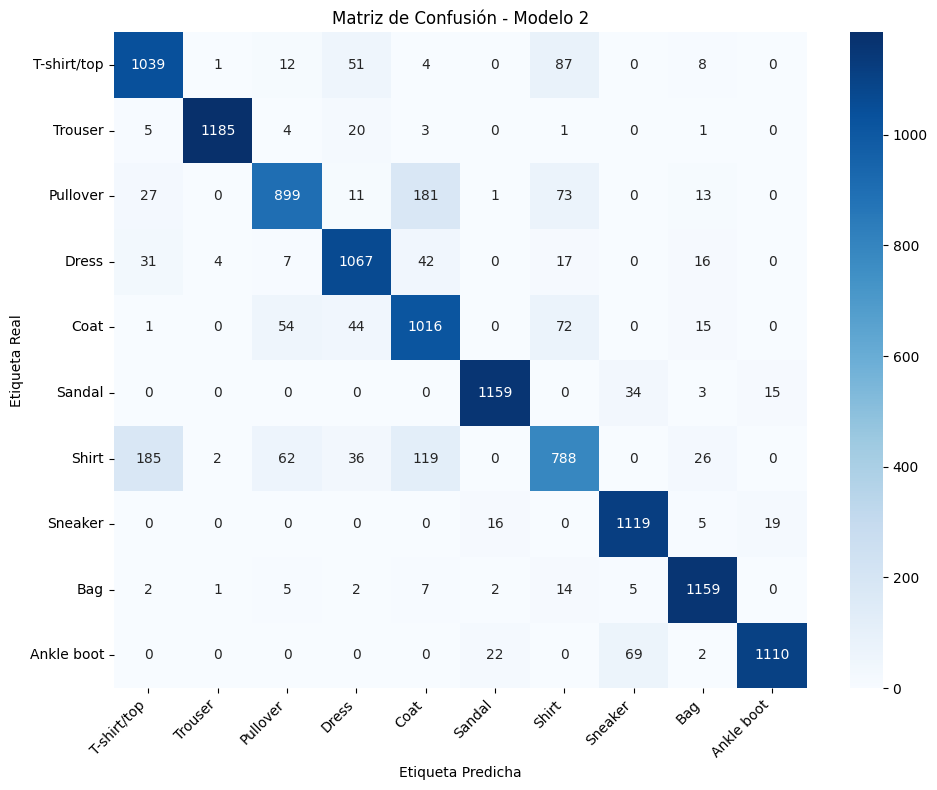

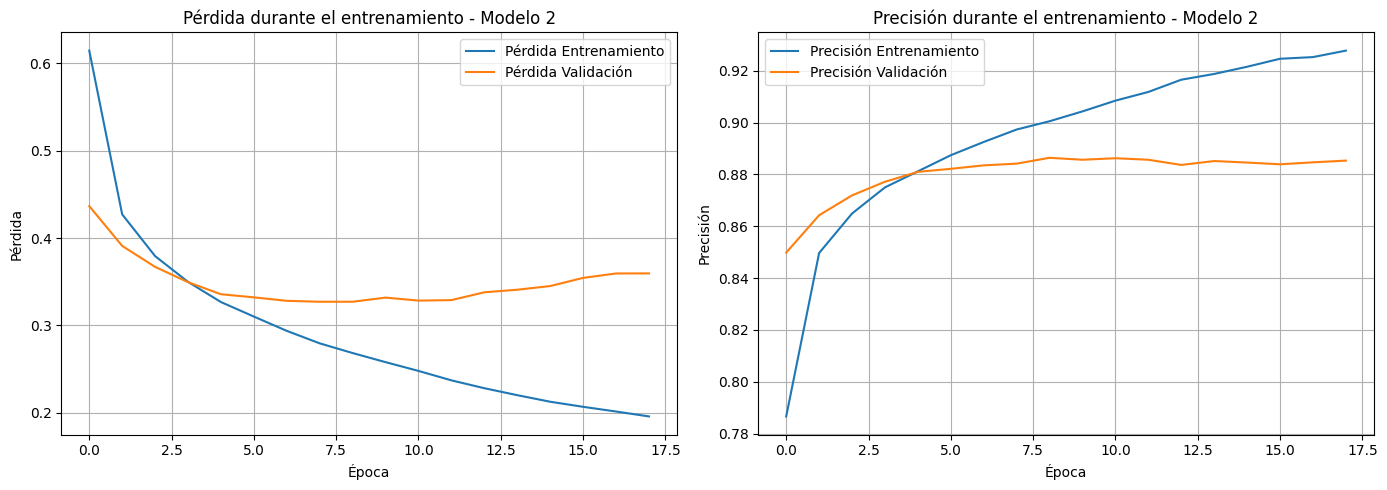


MODELO 2 completado.


In [19]:
# MODELO 2: Red Neuronal con imágenes aplanadas (784 características)
print("="*80)
print("MODELO 2: Red Neuronal con todas las características (píxeles)")
print("="*80)
print("Configuración: 784 características de entrada (28x28 píxeles aplanados)")
print("Arquitectura: Entrada(784) -> Dense(128, relu) -> Dense(64, relu) -> Salida(10, softmax)")
print("="*80 + "\n")

# Aplanar imágenes: cada imagen de 28x28 se convierte en un vector de 784 elementos
X_flat = X_train_full.reshape(len(X_train_full), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

print(f"Forma de X_flat: {X_flat.shape}")
print(f"Forma de X_test_flat: {X_test_flat.shape}")

# División: 60% train, 20% validation, 20% test
print("\nSeparando datos: 60% train, 20% validation, 20% test...")
X_temp, X_test_2, y_temp, y_test_2 = train_test_split(X_flat, y_train_cat, test_size=0.20, random_state=42, shuffle=True)
X_train_2, X_val_2, y_train_2, y_val_2 = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, shuffle=True)

print(f"Tamaño conjunto de entrenamiento: {len(X_train_2)}")
print(f"Tamaño conjunto de validación: {len(X_val_2)}")
print(f"Tamaño conjunto de test: {len(X_test_2)}")

# Normalización (0-1)
print("\nNormalizando píxeles a rango [0, 1]...")
X_train_2_scaled = X_train_2 / 255.0
X_val_2_scaled = X_val_2 / 255.0
X_test_2_scaled = X_test_2 / 255.0

print(f"Rango después de normalización: [{X_train_2_scaled.min():.2f}, {X_train_2_scaled.max():.2f}]")

# Construcción del modelo
model_2 = Sequential([
    Dense(128, activation='relu', input_shape=(784,), name='hidden_layer_1'),
    Dense(64, activation='relu', name='hidden_layer_2'),
    Dense(10, activation='softmax', name='output_layer')
])

model_2.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

print("\nResumen del modelo:")
model_2.summary()

# Entrenamiento con early stopping
early_stop_2 = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

print("\nEntrenando modelo...")
history_2 = model_2.fit(X_train_2_scaled, y_train_2,
                        epochs=50,
                        batch_size=128,
                        validation_data=(X_val_2_scaled, y_val_2),
                        callbacks=[early_stop_2],
                        verbose=1)

# Evaluación
print("\n--- Evaluación en conjunto de test ---")
test_loss_2, test_accuracy_2 = model_2.evaluate(X_test_2_scaled, y_test_2, verbose=0)
print(f"Pérdida en test: {test_loss_2:.4f}")
print(f"Precisión en test: {test_accuracy_2:.4f}")

# Predicciones
y_pred_2 = model_2.predict(X_test_2_scaled, verbose=0)
y_pred_classes_2 = np.argmax(y_pred_2, axis=1)
y_test_classes_2 = np.argmax(y_test_2, axis=1)

# Métricas detalladas
print("\n--- Métricas Detalladas ---")
print(f"Accuracy: {accuracy_score(y_test_classes_2, y_pred_classes_2):.4f}")
print(f"Precision (macro): {precision_score(y_test_classes_2, y_pred_classes_2, average='macro', zero_division=0):.4f}")
print(f"Recall (macro): {recall_score(y_test_classes_2, y_pred_classes_2, average='macro', zero_division=0):.4f}")
print(f"F1-Score (macro): {f1_score(y_test_classes_2, y_pred_classes_2, average='macro', zero_division=0):.4f}")

# Reporte de clasificación
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test_classes_2, y_pred_classes_2, target_names=class_names, zero_division=0))

# Matriz de confusión
cm_2 = confusion_matrix(y_test_classes_2, y_pred_classes_2)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_2, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión - Modelo 2')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Gráfico de pérdida y precisión
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_2.history['loss'], label='Pérdida Entrenamiento')
ax1.plot(history_2.history['val_loss'], label='Pérdida Validación')
ax1.set_title('Pérdida durante el entrenamiento - Modelo 2')
ax1.set_xlabel('Época')
ax1.set_ylabel('Pérdida')
ax1.legend()
ax1.grid(True)

ax2.plot(history_2.history['accuracy'], label='Precisión Entrenamiento')
ax2.plot(history_2.history['val_accuracy'], label='Precisión Validación')
ax2.set_title('Precisión durante el entrenamiento - Modelo 2')
ax2.set_xlabel('Época')
ax2.set_ylabel('Precisión')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\nMODELO 2 completado.")

MODELO 3: Red Neuronal Profunda con Dropout
Configuración: 784 características de entrada
Arquitectura: Entrada(784) -> Dense(256, relu) -> Dropout(0.3) -> Dense(128, relu) -> Dropout(0.2) -> Dense(64, relu) -> Salida(10, softmax)

Forma de X_train_2_scaled: (36000, 784)
Forma de X_val_2_scaled: (12000, 784)
Forma de X_test_2_scaled: (12000, 784)

Resumen del modelo:


c:\Users\ampr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_3 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)


Entrenando modelo...
Epoch 1/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7471 - loss: 0.7010 - val_accuracy: 0.8456 - val_loss: 0.4341
Epoch 2/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8339 - loss: 0.4622 - val_accuracy: 0.8634 - val_loss: 0.3819
Epoch 3/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8479 - loss: 0.4190 - val_accuracy: 0.8728 - val_loss: 0.3590
Epoch 4/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8560 - loss: 0.3961 - val_accuracy: 0.8726 - val_loss: 0.3453
Epoch 5/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8633 - loss: 0.3743 - val_accuracy: 0.8771 - val_loss: 0.3399
Epoch 6/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8674 - loss: 0.3551 - val_accuracy: 0.8814 - val_loss: 0.3275
Epoch 7/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8724 - loss: 0.3487 - val_accuracy: 0.8792 - val_loss: 0.3332
Epoch 8/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8776 - l

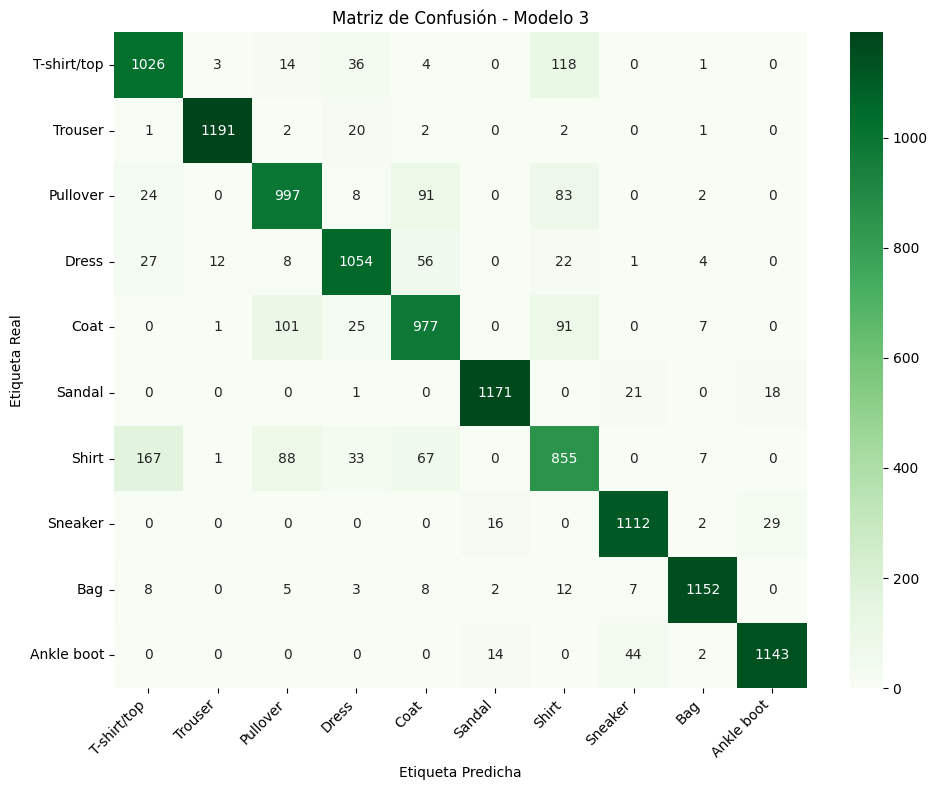

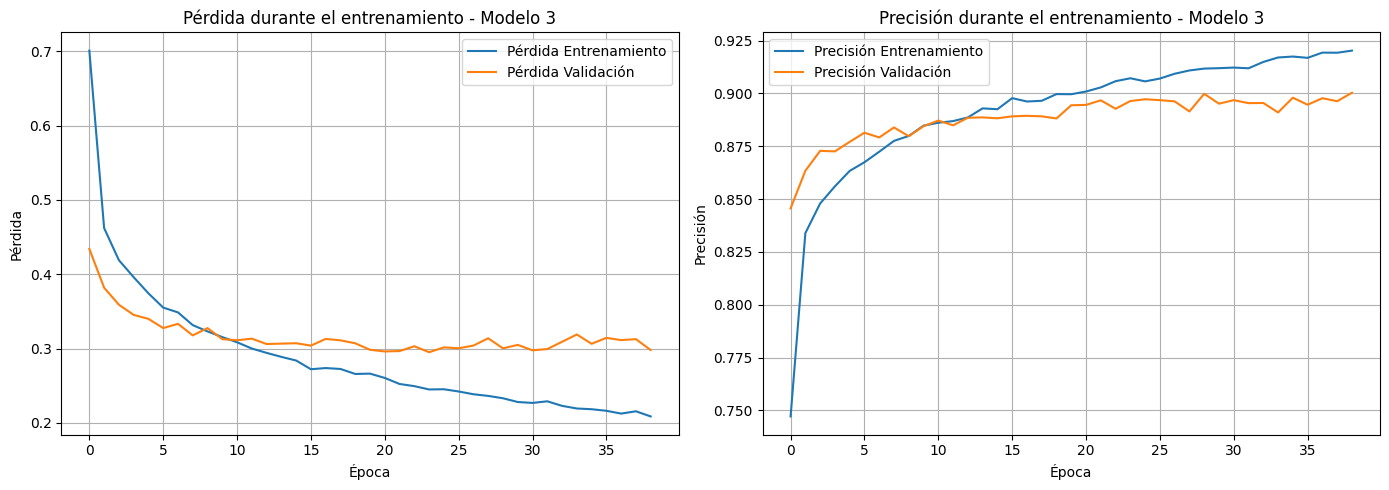


MODELO 3 completado.


In [20]:
# MODELO 3: Red Neuronal Profunda con Dropout
print("="*80)
print("MODELO 3: Red Neuronal Profunda con Dropout")
print("="*80)
print("Configuración: 784 características de entrada")
print("Arquitectura: Entrada(784) -> Dense(256, relu) -> Dropout(0.3) -> Dense(128, relu) -> Dropout(0.2) -> Dense(64, relu) -> Salida(10, softmax)")
print("="*80 + "\n")

# Usamos los mismos datos ya preparados del modelo 2
print(f"Forma de X_train_2_scaled: {X_train_2_scaled.shape}")
print(f"Forma de X_val_2_scaled: {X_val_2_scaled.shape}")
print(f"Forma de X_test_2_scaled: {X_test_2_scaled.shape}")

# Construcción del modelo con Dropout
model_3 = Sequential([
    Dense(256, activation='relu', input_shape=(784,), name='hidden_layer_1'),
    Dropout(0.3, name='dropout_1'),
    Dense(128, activation='relu', name='hidden_layer_2'),
    Dropout(0.2, name='dropout_2'),
    Dense(64, activation='relu', name='hidden_layer_3'),
    Dense(10, activation='softmax', name='output_layer')
])

model_3.compile(optimizer=Adam(learning_rate=0.001),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

print("\nResumen del modelo:")
model_3.summary()

# Entrenamiento con early stopping
early_stop_3 = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)

print("\nEntrenando modelo...")
history_3 = model_3.fit(X_train_2_scaled, y_train_2,
                        epochs=100,
                        batch_size=128,
                        validation_data=(X_val_2_scaled, y_val_2),
                        callbacks=[early_stop_3],
                        verbose=1)

# Evaluación
print("\n--- Evaluación en conjunto de test ---")
test_loss_3, test_accuracy_3 = model_3.evaluate(X_test_2_scaled, y_test_2, verbose=0)
print(f"Pérdida en test: {test_loss_3:.4f}")
print(f"Precisión en test: {test_accuracy_3:.4f}")

# Predicciones
y_pred_3 = model_3.predict(X_test_2_scaled, verbose=0)
y_pred_classes_3 = np.argmax(y_pred_3, axis=1)
y_test_classes_3 = np.argmax(y_test_2, axis=1)

# Métricas detalladas
print("\n--- Métricas Detalladas ---")
print(f"Accuracy: {accuracy_score(y_test_classes_3, y_pred_classes_3):.4f}")
print(f"Precision (macro): {precision_score(y_test_classes_3, y_pred_classes_3, average='macro', zero_division=0):.4f}")
print(f"Recall (macro): {recall_score(y_test_classes_3, y_pred_classes_3, average='macro', zero_division=0):.4f}")
print(f"F1-Score (macro): {f1_score(y_test_classes_3, y_pred_classes_3, average='macro', zero_division=0):.4f}")

# Reporte de clasificación
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test_classes_3, y_pred_classes_3, target_names=class_names, zero_division=0))

# Matriz de confusión
cm_3 = confusion_matrix(y_test_classes_3, y_pred_classes_3)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_3, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión - Modelo 3')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Gráfico de pérdida y precisión
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_3.history['loss'], label='Pérdida Entrenamiento')
ax1.plot(history_3.history['val_loss'], label='Pérdida Validación')
ax1.set_title('Pérdida durante el entrenamiento - Modelo 3')
ax1.set_xlabel('Época')
ax1.set_ylabel('Pérdida')
ax1.legend()
ax1.grid(True)

ax2.plot(history_3.history['accuracy'], label='Precisión Entrenamiento')
ax2.plot(history_3.history['val_accuracy'], label='Precisión Validación')
ax2.set_title('Precisión durante el entrenamiento - Modelo 3')
ax2.set_xlabel('Época')
ax2.set_ylabel('Precisión')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\nMODELO 3 completado.")

MODELO 4: Red Neuronal con optimizador SGD
Configuración: 784 características de entrada
Arquitectura: Entrada(784) -> Dense(128, relu) -> Dense(64, relu) -> Salida(10, softmax)
Optimizador: SGD (Stochastic Gradient Descent) con momentum


Resumen del modelo:


c:\Users\ampr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


Entrenando modelo...
Epoch 1/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7394 - loss: 0.7585 - val_accuracy: 0.8273 - val_loss: 0.4988
Epoch 2/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8275 - loss: 0.4848 - val_accuracy: 0.8426 - val_loss: 0.4458
Epoch 3/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8464 - loss: 0.4362 - val_accuracy: 0.8613 - val_loss: 0.4015
Epoch 4/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8558 - loss: 0.4071 - val_accuracy: 0.8643 - val_loss: 0.3885
Epoch 5/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8634 - loss: 0.3854 - val_accuracy: 0.8689 - val_loss: 0.3793
Epoch 6/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8697 - loss: 0.3690 - val_accuracy: 0.8732 - val_loss: 0.3695
Epoch 7/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8731 - loss: 0.3547 - val_accuracy: 0.8743 - val_loss: 0.3599
Epoch 8/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8777 - l

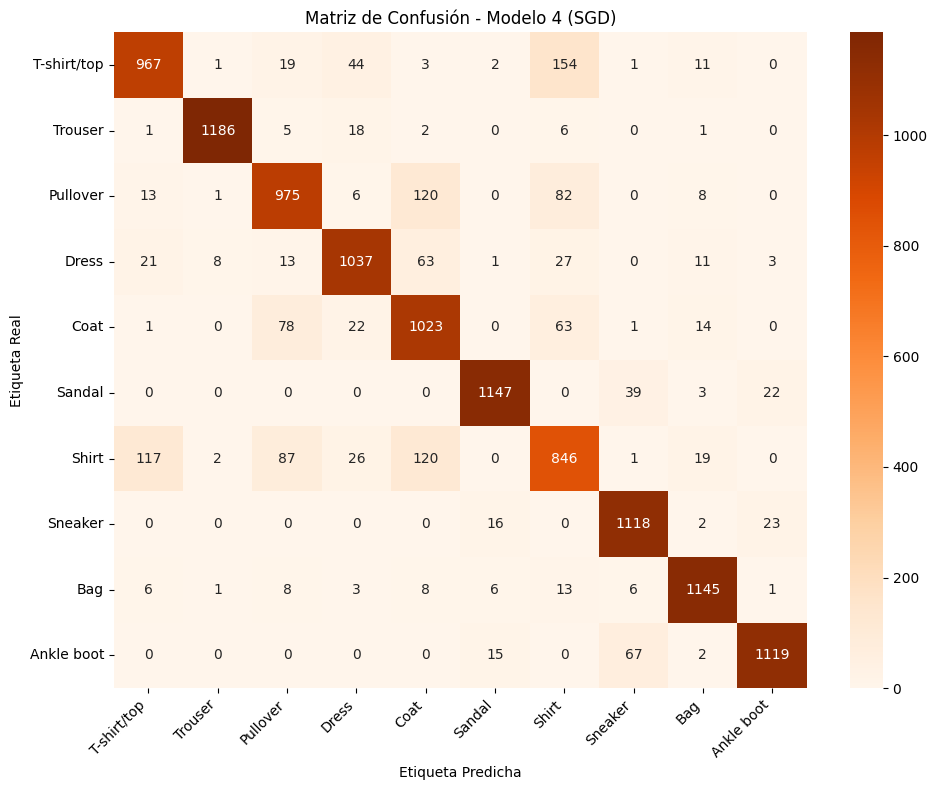

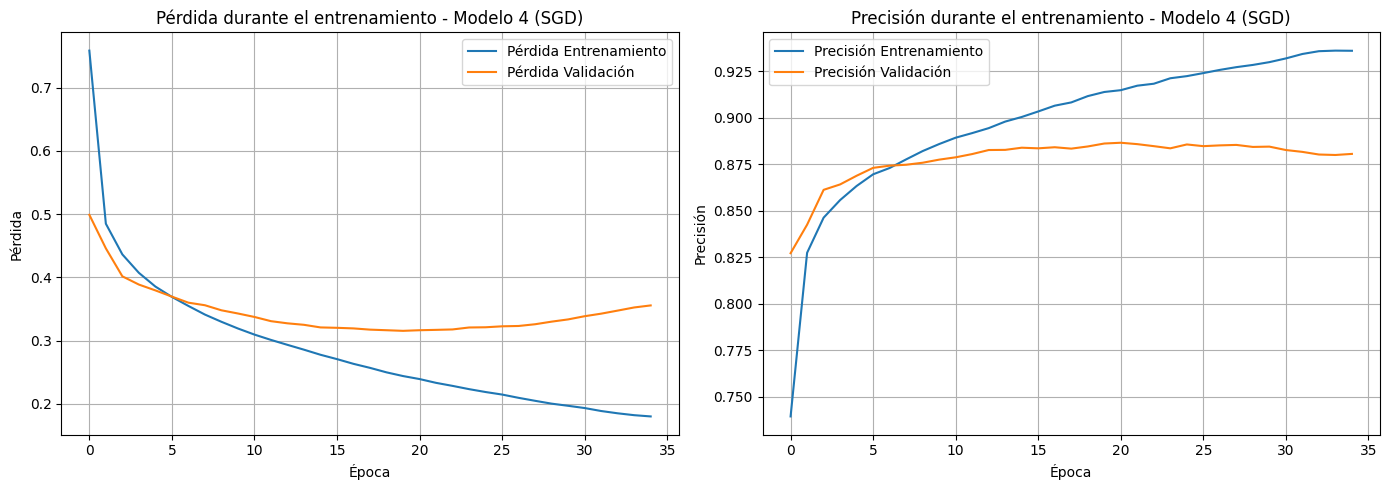


MODELO 4 completado.


In [21]:
# MODELO 4: Red Neuronal con diferentes optimizadores (SGD)
print("="*80)
print("MODELO 4: Red Neuronal con optimizador SGD")
print("="*80)
print("Configuración: 784 características de entrada")
print("Arquitectura: Entrada(784) -> Dense(128, relu) -> Dense(64, relu) -> Salida(10, softmax)")
print("Optimizador: SGD (Stochastic Gradient Descent) con momentum")
print("="*80 + "\n")

# Construcción del modelo
model_4 = Sequential([
    Dense(128, activation='relu', input_shape=(784,), name='hidden_layer_1'),
    Dense(64, activation='relu', name='hidden_layer_2'),
    Dense(10, activation='softmax', name='output_layer')
])

# Compilar con SGD
model_4.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

print("\nResumen del modelo:")
model_4.summary()

# Entrenamiento con early stopping
early_stop_4 = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)

print("\nEntrenando modelo...")
history_4 = model_4.fit(X_train_2_scaled, y_train_2,
                        epochs=100,
                        batch_size=128,
                        validation_data=(X_val_2_scaled, y_val_2),
                        callbacks=[early_stop_4],
                        verbose=1)

# Evaluación
print("\n--- Evaluación en conjunto de test ---")
test_loss_4, test_accuracy_4 = model_4.evaluate(X_test_2_scaled, y_test_2, verbose=0)
print(f"Pérdida en test: {test_loss_4:.4f}")
print(f"Precisión en test: {test_accuracy_4:.4f}")

# Predicciones
y_pred_4 = model_4.predict(X_test_2_scaled, verbose=0)
y_pred_classes_4 = np.argmax(y_pred_4, axis=1)
y_test_classes_4 = np.argmax(y_test_2, axis=1)

# Métricas detalladas
print("\n--- Métricas Detalladas ---")
print(f"Accuracy: {accuracy_score(y_test_classes_4, y_pred_classes_4):.4f}")
print(f"Precision (macro): {precision_score(y_test_classes_4, y_pred_classes_4, average='macro', zero_division=0):.4f}")
print(f"Recall (macro): {recall_score(y_test_classes_4, y_pred_classes_4, average='macro', zero_division=0):.4f}")
print(f"F1-Score (macro): {f1_score(y_test_classes_4, y_pred_classes_4, average='macro', zero_division=0):.4f}")

# Reporte de clasificación
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test_classes_4, y_pred_classes_4, target_names=class_names, zero_division=0))

# Matriz de confusión
cm_4 = confusion_matrix(y_test_classes_4, y_pred_classes_4)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_4, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión - Modelo 4 (SGD)')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Gráfico de pérdida y precisión
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_4.history['loss'], label='Pérdida Entrenamiento')
ax1.plot(history_4.history['val_loss'], label='Pérdida Validación')
ax1.set_title('Pérdida durante el entrenamiento - Modelo 4 (SGD)')
ax1.set_xlabel('Época')
ax1.set_ylabel('Pérdida')
ax1.legend()
ax1.grid(True)

ax2.plot(history_4.history['accuracy'], label='Precisión Entrenamiento')
ax2.plot(history_4.history['val_accuracy'], label='Precisión Validación')
ax2.set_title('Precisión durante el entrenamiento - Modelo 4 (SGD)')
ax2.set_xlabel('Época')
ax2.set_ylabel('Precisión')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\nMODELO 4 completado.")

MODELO 5: Red Neuronal con optimizador RMSprop
Configuración: 784 características de entrada
Arquitectura: Entrada(784) -> Dense(128, relu) -> Dense(64, relu) -> Salida(10, softmax)
Optimizador: RMSprop


Resumen del modelo:


c:\Users\ampr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


Entrenando modelo...
Epoch 1/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7689 - loss: 0.6540 - val_accuracy: 0.8178 - val_loss: 0.5334
Epoch 2/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8400 - loss: 0.4440 - val_accuracy: 0.8432 - val_loss: 0.4587
Epoch 3/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8587 - loss: 0.3884 - val_accuracy: 0.8568 - val_loss: 0.4062
Epoch 4/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8716 - loss: 0.3542 - val_accuracy: 0.8643 - val_loss: 0.3846
Epoch 5/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8796 - loss: 0.3295 - val_accuracy: 0.8698 - val_loss: 0.3661
Epoch 6/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8873 - loss: 0.3093 - val_accuracy: 0.8756 - val_loss: 0.3461
Epoch 7/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8925 - loss: 0.2939 - val_accuracy: 0.8708 - val_loss: 0.3581
Epoch 8/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8978 - l

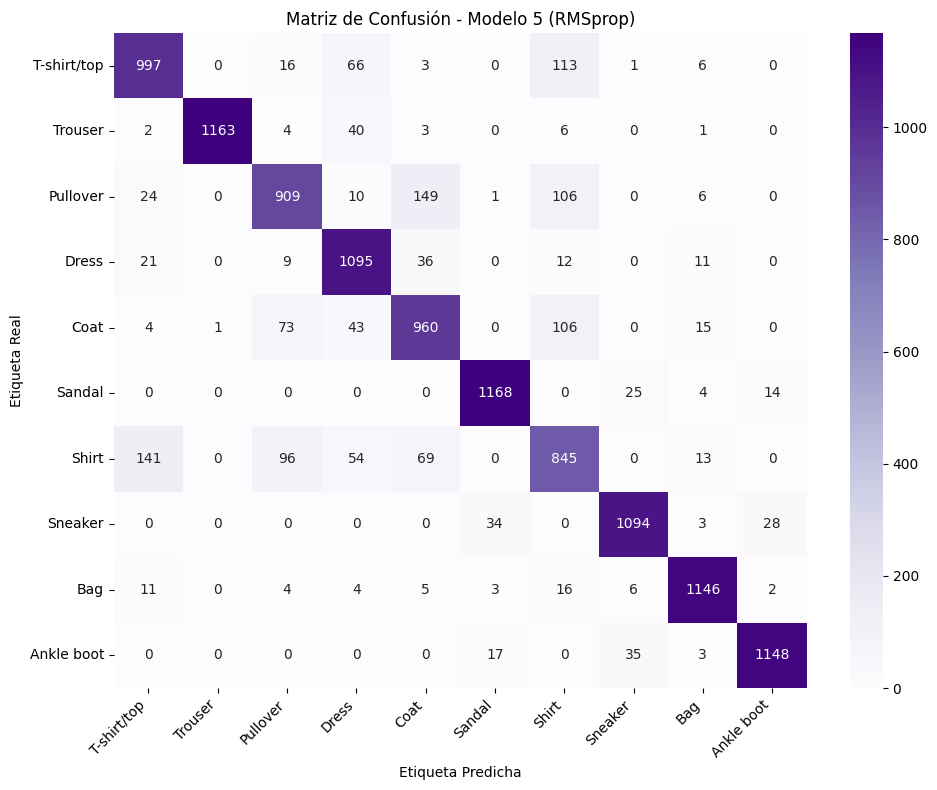

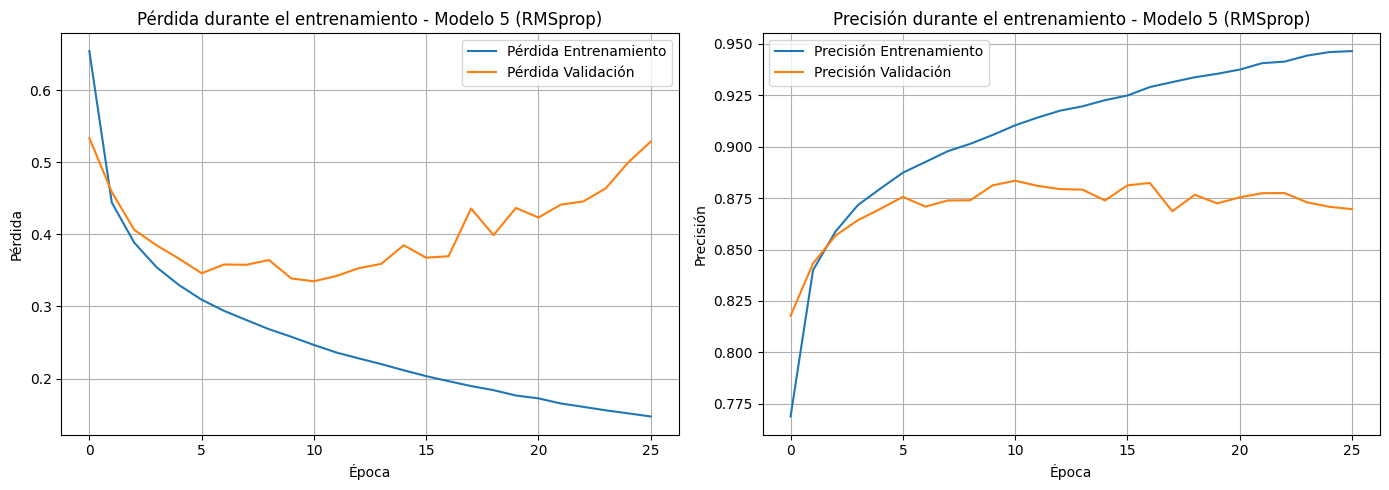


MODELO 5 completado.


In [22]:
# MODELO 5: Red Neuronal con optimizador RMSprop
print("="*80)
print("MODELO 5: Red Neuronal con optimizador RMSprop")
print("="*80)
print("Configuración: 784 características de entrada")
print("Arquitectura: Entrada(784) -> Dense(128, relu) -> Dense(64, relu) -> Salida(10, softmax)")
print("Optimizador: RMSprop")
print("="*80 + "\n")

# Construcción del modelo
model_5 = Sequential([
    Dense(128, activation='relu', input_shape=(784,), name='hidden_layer_1'),
    Dense(64, activation='relu', name='hidden_layer_2'),
    Dense(10, activation='softmax', name='output_layer')
])

# Compilar con RMSprop
model_5.compile(optimizer=RMSprop(learning_rate=0.001),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

print("\nResumen del modelo:")
model_5.summary()

# Entrenamiento con early stopping
early_stop_5 = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)

print("\nEntrenando modelo...")
history_5 = model_5.fit(X_train_2_scaled, y_train_2,
                        epochs=100,
                        batch_size=128,
                        validation_data=(X_val_2_scaled, y_val_2),
                        callbacks=[early_stop_5],
                        verbose=1)

# Evaluación
print("\n--- Evaluación en conjunto de test ---")
test_loss_5, test_accuracy_5 = model_5.evaluate(X_test_2_scaled, y_test_2, verbose=0)
print(f"Pérdida en test: {test_loss_5:.4f}")
print(f"Precisión en test: {test_accuracy_5:.4f}")

# Predicciones
y_pred_5 = model_5.predict(X_test_2_scaled, verbose=0)
y_pred_classes_5 = np.argmax(y_pred_5, axis=1)
y_test_classes_5 = np.argmax(y_test_2, axis=1)

# Métricas detalladas
print("\n--- Métricas Detalladas ---")
print(f"Accuracy: {accuracy_score(y_test_classes_5, y_pred_classes_5):.4f}")
print(f"Precision (macro): {precision_score(y_test_classes_5, y_pred_classes_5, average='macro', zero_division=0):.4f}")
print(f"Recall (macro): {recall_score(y_test_classes_5, y_pred_classes_5, average='macro', zero_division=0):.4f}")
print(f"F1-Score (macro): {f1_score(y_test_classes_5, y_pred_classes_5, average='macro', zero_division=0):.4f}")

# Reporte de clasificación
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test_classes_5, y_pred_classes_5, target_names=class_names, zero_division=0))

# Matriz de confusión
cm_5 = confusion_matrix(y_test_classes_5, y_pred_classes_5)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_5, annot=True, fmt='d', cmap='Purples', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión - Modelo 5 (RMSprop)')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Gráfico de pérdida y precisión
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_5.history['loss'], label='Pérdida Entrenamiento')
ax1.plot(history_5.history['val_loss'], label='Pérdida Validación')
ax1.set_title('Pérdida durante el entrenamiento - Modelo 5 (RMSprop)')
ax1.set_xlabel('Época')
ax1.set_ylabel('Pérdida')
ax1.legend()
ax1.grid(True)

ax2.plot(history_5.history['accuracy'], label='Precisión Entrenamiento')
ax2.plot(history_5.history['val_accuracy'], label='Precisión Validación')
ax2.set_title('Precisión durante el entrenamiento - Modelo 5 (RMSprop)')
ax2.set_xlabel('Época')
ax2.set_ylabel('Precisión')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\nMODELO 5 completado.")

MODELO 6: Red Neuronal con Flatten layer
Configuración: Entrada de imágenes 28x28 (sin aplanar manualmente)
Arquitectura: Flatten -> Dense(256, relu) -> Dropout(0.3) -> Dense(128, relu) -> Dropout(0.2) -> Dense(10, softmax)

Forma de X_train_img: (48000, 28, 28)
Forma de X_val_img: (12000, 28, 28)
Forma de X_test_img: (10000, 28, 28)

Resumen del modelo:


c:\Users\ampr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_1 (Dense)          │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)


Entrenando modelo...
Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7772 - loss: 0.6205 - val_accuracy: 0.8479 - val_loss: 0.4248
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8421 - loss: 0.4337 - val_accuracy: 0.8631 - val_loss: 0.3772
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8556 - loss: 0.3941 - val_accuracy: 0.8648 - val_loss: 0.3631
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8629 - loss: 0.3733 - val_accuracy: 0.8675 - val_loss: 0.3581
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8693 - loss: 0.3546 - val_accuracy: 0.8727 - val_loss: 0.3477
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8729 - loss: 0.3405 - val_accuracy: 0.8757 - val_loss: 0.3369
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8786 - loss: 0.3249 - val_accuracy: 0.8792 - val_loss: 0.3335
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8843 - l

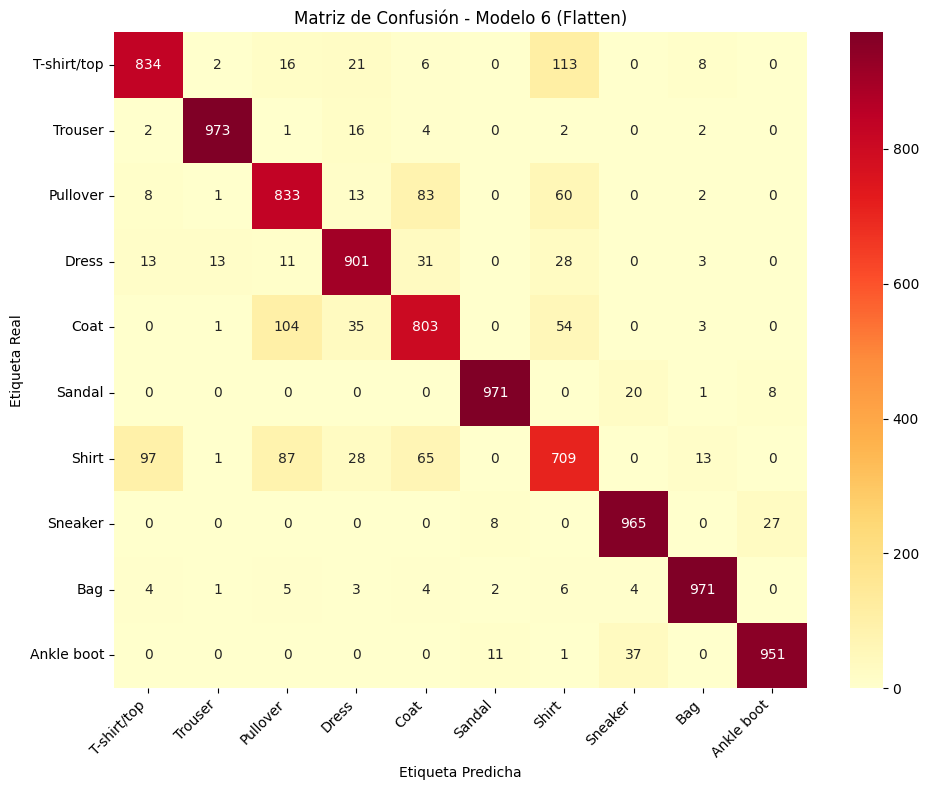

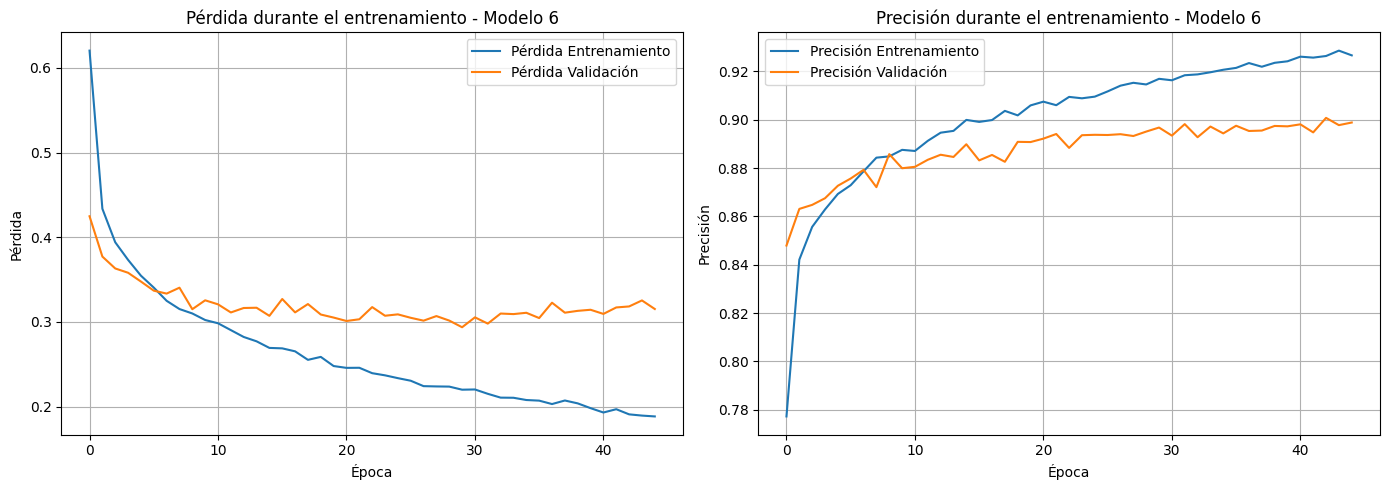


MODELO 6 completado.


In [23]:
# MODELO 6: Red Neuronal con Flatten layer y arquitectura mejorada
print("="*80)
print("MODELO 6: Red Neuronal con Flatten layer")
print("="*80)
print("Configuración: Entrada de imágenes 28x28 (sin aplanar manualmente)")
print("Arquitectura: Flatten -> Dense(256, relu) -> Dropout(0.3) -> Dense(128, relu) -> Dropout(0.2) -> Dense(10, softmax)")
print("="*80 + "\n")

# Para este modelo, usaremos las imágenes sin aplanar
X_train_img = X_train_full[:int(len(X_train_full)*0.8)]
X_val_img = X_train_full[int(len(X_train_full)*0.8):]
y_train_img = y_train_cat[:int(len(y_train_cat)*0.8)]
y_val_img = y_train_cat[int(len(y_train_cat)*0.8):]

# Normalizar
X_train_img = X_train_img / 255.0
X_val_img = X_val_img / 255.0
X_test_img = X_test / 255.0

print(f"Forma de X_train_img: {X_train_img.shape}")
print(f"Forma de X_val_img: {X_val_img.shape}")
print(f"Forma de X_test_img: {X_test_img.shape}")

# Construcción del modelo con Flatten
model_6 = Sequential([
    Flatten(input_shape=(28, 28), name='flatten'),
    Dense(256, activation='relu', name='hidden_layer_1'),
    Dropout(0.3, name='dropout_1'),
    Dense(128, activation='relu', name='hidden_layer_2'),
    Dropout(0.2, name='dropout_2'),
    Dense(10, activation='softmax', name='output_layer')
])

model_6.compile(optimizer=Adam(learning_rate=0.001),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

print("\nResumen del modelo:")
model_6.summary()

# Entrenamiento con early stopping
early_stop_6 = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)

print("\nEntrenando modelo...")
history_6 = model_6.fit(X_train_img, y_train_img,
                        epochs=100,
                        batch_size=128,
                        validation_data=(X_val_img, y_val_img),
                        callbacks=[early_stop_6],
                        verbose=1)

# Evaluación
print("\n--- Evaluación en conjunto de test ---")
test_loss_6, test_accuracy_6 = model_6.evaluate(X_test_img, y_test_cat, verbose=0)
print(f"Pérdida en test: {test_loss_6:.4f}")
print(f"Precisión en test: {test_accuracy_6:.4f}")

# Predicciones
y_pred_6 = model_6.predict(X_test_img, verbose=0)
y_pred_classes_6 = np.argmax(y_pred_6, axis=1)
y_test_classes_6 = np.argmax(y_test_cat, axis=1)

# Métricas detalladas
print("\n--- Métricas Detalladas ---")
print(f"Accuracy: {accuracy_score(y_test_classes_6, y_pred_classes_6):.4f}")
print(f"Precision (macro): {precision_score(y_test_classes_6, y_pred_classes_6, average='macro', zero_division=0):.4f}")
print(f"Recall (macro): {recall_score(y_test_classes_6, y_pred_classes_6, average='macro', zero_division=0):.4f}")
print(f"F1-Score (macro): {f1_score(y_test_classes_6, y_pred_classes_6, average='macro', zero_division=0):.4f}")

# Reporte de clasificación
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test_classes_6, y_pred_classes_6, target_names=class_names, zero_division=0))

# Matriz de confusión
cm_6 = confusion_matrix(y_test_classes_6, y_pred_classes_6)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_6, annot=True, fmt='d', cmap='YlOrRd', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión - Modelo 6 (Flatten)')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Gráfico de pérdida y precisión
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_6.history['loss'], label='Pérdida Entrenamiento')
ax1.plot(history_6.history['val_loss'], label='Pérdida Validación')
ax1.set_title('Pérdida durante el entrenamiento - Modelo 6')
ax1.set_xlabel('Época')
ax1.set_ylabel('Pérdida')
ax1.legend()
ax1.grid(True)

ax2.plot(history_6.history['accuracy'], label='Precisión Entrenamiento')
ax2.plot(history_6.history['val_accuracy'], label='Precisión Validación')
ax2.set_title('Precisión durante el entrenamiento - Modelo 6')
ax2.set_xlabel('Época')
ax2.set_ylabel('Precisión')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\nMODELO 6 completado.")

## Comparación de Modelos

A continuación se comparan todos los modelos entrenados para determinar cuál tiene el mejor rendimiento en el conjunto de test.

COMPARACIÓN DE MODELOS

                                 Test Loss  Test Accuracy  F1-Score
Modelo 1 (1 feature - promedio)   1.938699       0.279167  0.215154
Modelo 2 (784 features)           0.340978       0.878417  0.877697
Modelo 3 (Dropout)                0.311096       0.889833  0.890135
Modelo 4 (SGD)                    0.335891       0.880250  0.880586
Modelo 5 (RMSprop)                0.363997       0.877083  0.877199
Modelo 6 (Flatten)                0.330263       0.891100  0.891020


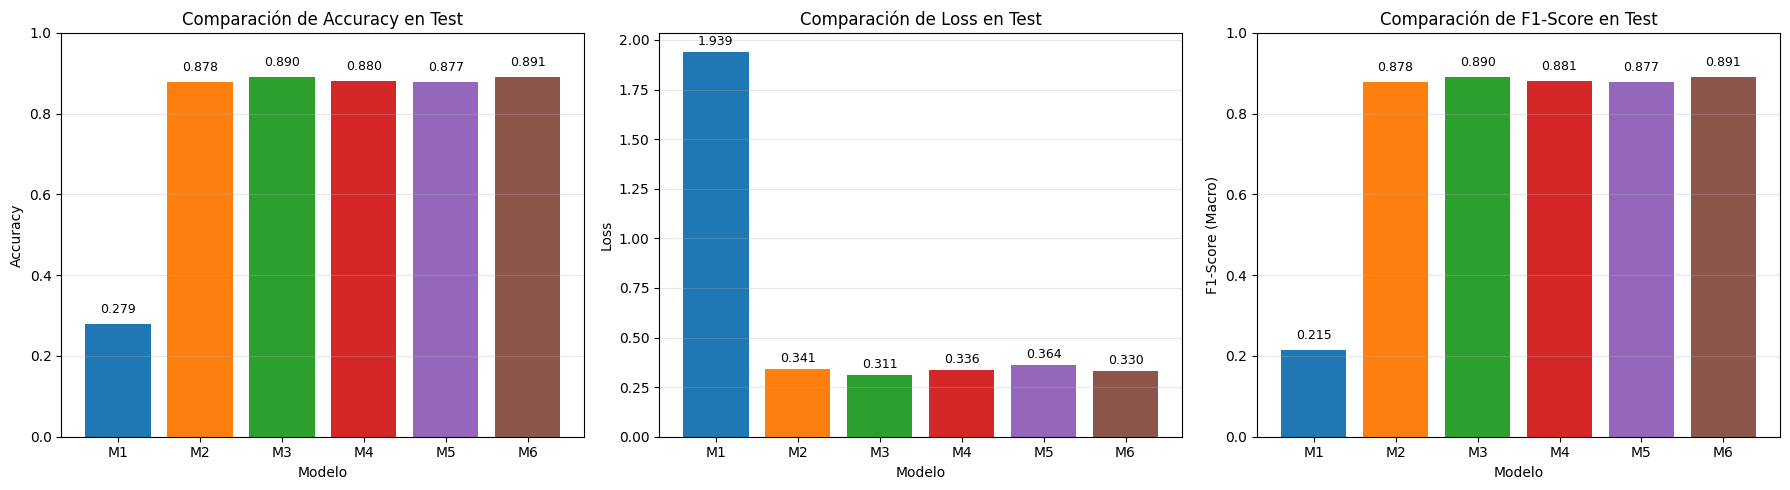


MEJOR MODELO: Modelo 6 (Flatten)
Accuracy: 0.8911
Loss: 0.3303
F1-Score: 0.8910


In [24]:
# Comparación de todos los modelos
print("="*80)
print("COMPARACIÓN DE MODELOS")
print("="*80 + "\n")

# Recopilar métricas de todos los modelos
modelos_comparacion = {
    'Modelo 1 (1 feature - promedio)': {
        'Test Loss': test_loss_1,
        'Test Accuracy': test_accuracy_1,
        'F1-Score': f1_score(y_test_classes_1, y_pred_classes_1, average='macro', zero_division=0)
    },
    'Modelo 2 (784 features)': {
        'Test Loss': test_loss_2,
        'Test Accuracy': test_accuracy_2,
        'F1-Score': f1_score(y_test_classes_2, y_pred_classes_2, average='macro', zero_division=0)
    },
    'Modelo 3 (Dropout)': {
        'Test Loss': test_loss_3,
        'Test Accuracy': test_accuracy_3,
        'F1-Score': f1_score(y_test_classes_3, y_pred_classes_3, average='macro', zero_division=0)
    },
    'Modelo 4 (SGD)': {
        'Test Loss': test_loss_4,
        'Test Accuracy': test_accuracy_4,
        'F1-Score': f1_score(y_test_classes_4, y_pred_classes_4, average='macro', zero_division=0)
    },
    'Modelo 5 (RMSprop)': {
        'Test Loss': test_loss_5,
        'Test Accuracy': test_accuracy_5,
        'F1-Score': f1_score(y_test_classes_5, y_pred_classes_5, average='macro', zero_division=0)
    },
    'Modelo 6 (Flatten)': {
        'Test Loss': test_loss_6,
        'Test Accuracy': test_accuracy_6,
        'F1-Score': f1_score(y_test_classes_6, y_pred_classes_6, average='macro', zero_division=0)
    }
}

# Crear DataFrame para comparación
df_comparacion = pd.DataFrame(modelos_comparacion).T
print(df_comparacion.to_string())

# Visualización de comparación
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Test Accuracy
axes[0].bar(range(len(df_comparacion)), df_comparacion['Test Accuracy'], 
            color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'])
axes[0].set_xlabel('Modelo')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Comparación de Accuracy en Test')
axes[0].set_xticks(range(len(df_comparacion)))
axes[0].set_xticklabels([f'M{i+1}' for i in range(len(df_comparacion))], rotation=0)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1])

# Añadir valores sobre las barras
for i, v in enumerate(df_comparacion['Test Accuracy']):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

# Gráfico 2: Test Loss
axes[1].bar(range(len(df_comparacion)), df_comparacion['Test Loss'],
            color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'])
axes[1].set_xlabel('Modelo')
axes[1].set_ylabel('Loss')
axes[1].set_title('Comparación de Loss en Test')
axes[1].set_xticks(range(len(df_comparacion)))
axes[1].set_xticklabels([f'M{i+1}' for i in range(len(df_comparacion))], rotation=0)
axes[1].grid(axis='y', alpha=0.3)

# Añadir valores sobre las barras
for i, v in enumerate(df_comparacion['Test Loss']):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

# Gráfico 3: F1-Score
axes[2].bar(range(len(df_comparacion)), df_comparacion['F1-Score'],
            color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'])
axes[2].set_xlabel('Modelo')
axes[2].set_ylabel('F1-Score (Macro)')
axes[2].set_title('Comparación de F1-Score en Test')
axes[2].set_xticks(range(len(df_comparacion)))
axes[2].set_xticklabels([f'M{i+1}' for i in range(len(df_comparacion))], rotation=0)
axes[2].grid(axis='y', alpha=0.3)
axes[2].set_ylim([0, 1])

# Añadir valores sobre las barras
for i, v in enumerate(df_comparacion['F1-Score']):
    axes[2].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Encontrar el mejor modelo
mejor_modelo_idx = df_comparacion['Test Accuracy'].idxmax()
print(f"\n{'='*80}")
print(f"MEJOR MODELO: {mejor_modelo_idx}")
print(f"{'='*80}")
print(f"Accuracy: {df_comparacion.loc[mejor_modelo_idx, 'Test Accuracy']:.4f}")
print(f"Loss: {df_comparacion.loc[mejor_modelo_idx, 'Test Loss']:.4f}")
print(f"F1-Score: {df_comparacion.loc[mejor_modelo_idx, 'F1-Score']:.4f}")

VISUALIZACIÓN DE PREDICCIONES



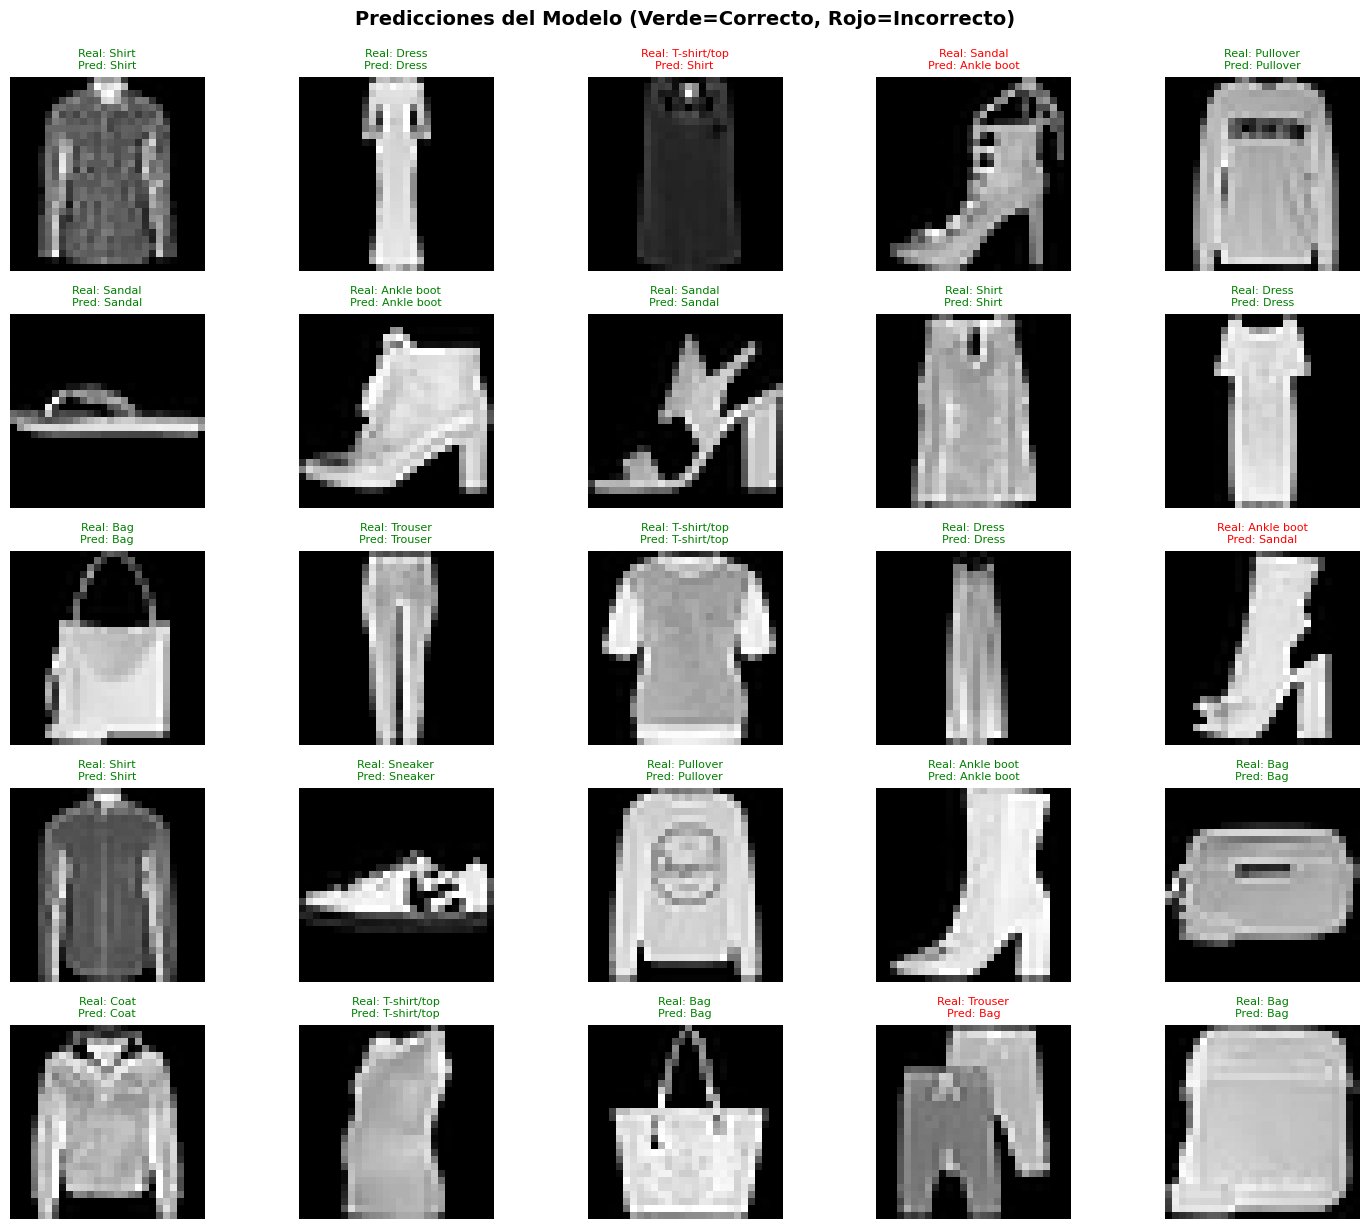


Buscando predicciones incorrectas...
Total de predicciones incorrectas: 1089 de 10000
Porcentaje de error: 10.89%


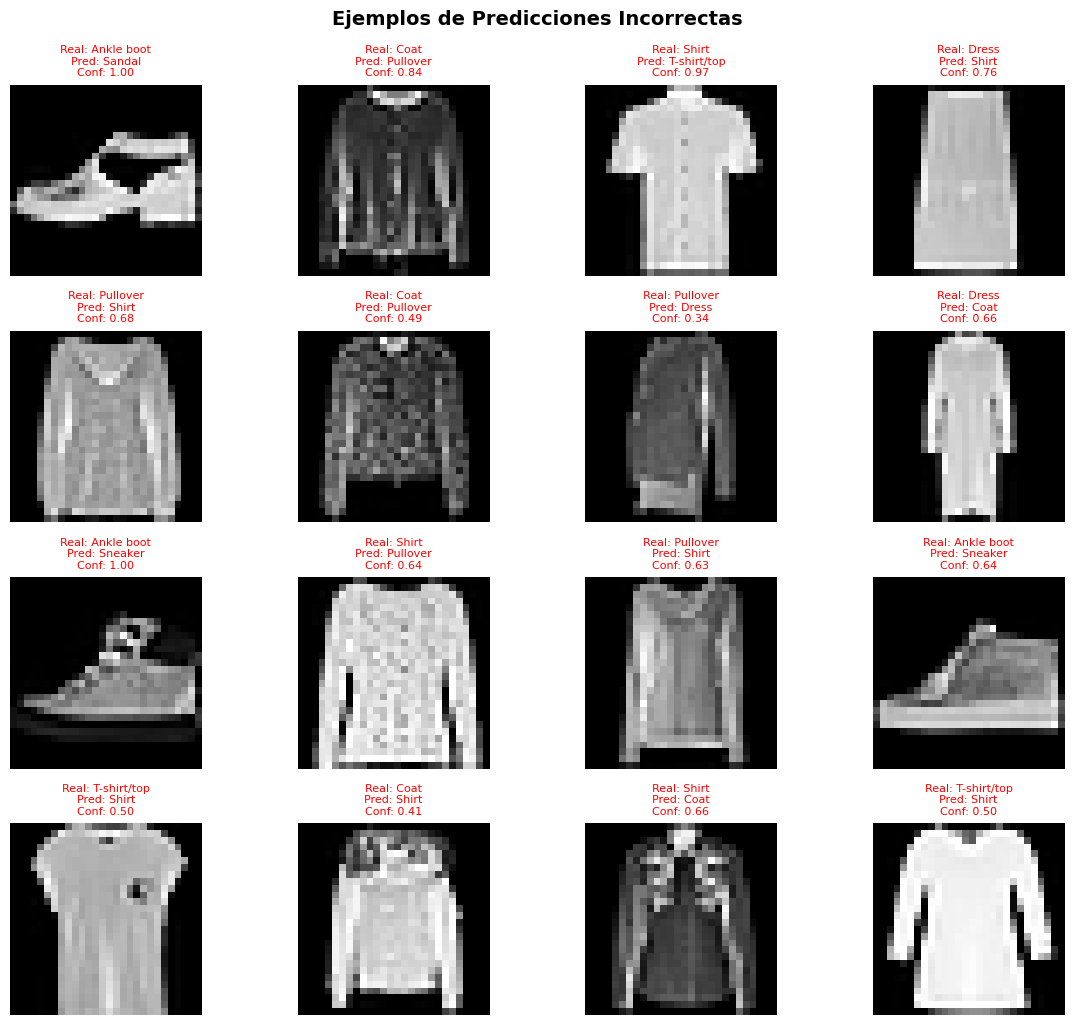

In [25]:
# Visualización de predicciones del mejor modelo
print("="*80)
print("VISUALIZACIÓN DE PREDICCIONES")
print("="*80 + "\n")

# Seleccionar algunas imágenes de prueba aleatoriamente
np.random.seed(42)
indices_aleatorios = np.random.choice(len(X_test), 25, replace=False)

# Usar el modelo 6 para las predicciones (o el mejor modelo identificado)
predicciones_visualizar = model_6.predict(X_test_img[indices_aleatorios], verbose=0)
clases_predichas_vis = np.argmax(predicciones_visualizar, axis=1)
clases_reales_vis = y_test[indices_aleatorios]

# Visualizar las predicciones
plt.figure(figsize=(15, 12))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_test[indices_aleatorios[i]], cmap='gray')
    
    # Color verde si es correcto, rojo si es incorrecto
    color = 'green' if clases_predichas_vis[i] == clases_reales_vis[i] else 'red'
    
    plt.title(f'Real: {class_names[clases_reales_vis[i]]}\n'
              f'Pred: {class_names[clases_predichas_vis[i]]}',
              fontsize=8, color=color)
    plt.axis('off')

plt.tight_layout()
plt.suptitle('Predicciones del Modelo (Verde=Correcto, Rojo=Incorrecto)', 
             y=1.02, fontsize=14, fontweight='bold')
plt.show()

# Mostrar algunas predicciones incorrectas
print("\nBuscando predicciones incorrectas...")
y_pred_all = model_6.predict(X_test_img, verbose=0)
y_pred_classes_all = np.argmax(y_pred_all, axis=1)

indices_incorrectos = np.where(y_pred_classes_all != y_test)[0]
print(f"Total de predicciones incorrectas: {len(indices_incorrectos)} de {len(y_test)}")
print(f"Porcentaje de error: {len(indices_incorrectos)/len(y_test)*100:.2f}%")

# Visualizar algunas predicciones incorrectas
if len(indices_incorrectos) > 0:
    num_mostrar = min(16, len(indices_incorrectos))
    indices_mostrar = indices_incorrectos[:num_mostrar]
    
    plt.figure(figsize=(12, 10))
    for i in range(num_mostrar):
        idx = indices_mostrar[i]
        plt.subplot(4, 4, i + 1)
        plt.imshow(X_test[idx], cmap='gray')
        
        pred_probs = y_pred_all[idx]
        pred_class = y_pred_classes_all[idx]
        real_class = y_test[idx]
        
        plt.title(f'Real: {class_names[real_class]}\n'
                  f'Pred: {class_names[pred_class]}\n'
                  f'Conf: {pred_probs[pred_class]:.2f}',
                  fontsize=8, color='red')
        plt.axis('off')
    
    plt.tight_layout()
    plt.suptitle('Ejemplos de Predicciones Incorrectas', y=1.02, fontsize=14, fontweight='bold')
    plt.show()
else:
    print("¡Increíble! No hay predicciones incorrectas.")

ANÁLISIS DE CONFIANZA DE PREDICCIONES

Confianza promedio: 0.9064
Confianza promedio en predicciones correctas: 0.9346
Confianza promedio en predicciones incorrectas: 0.6751


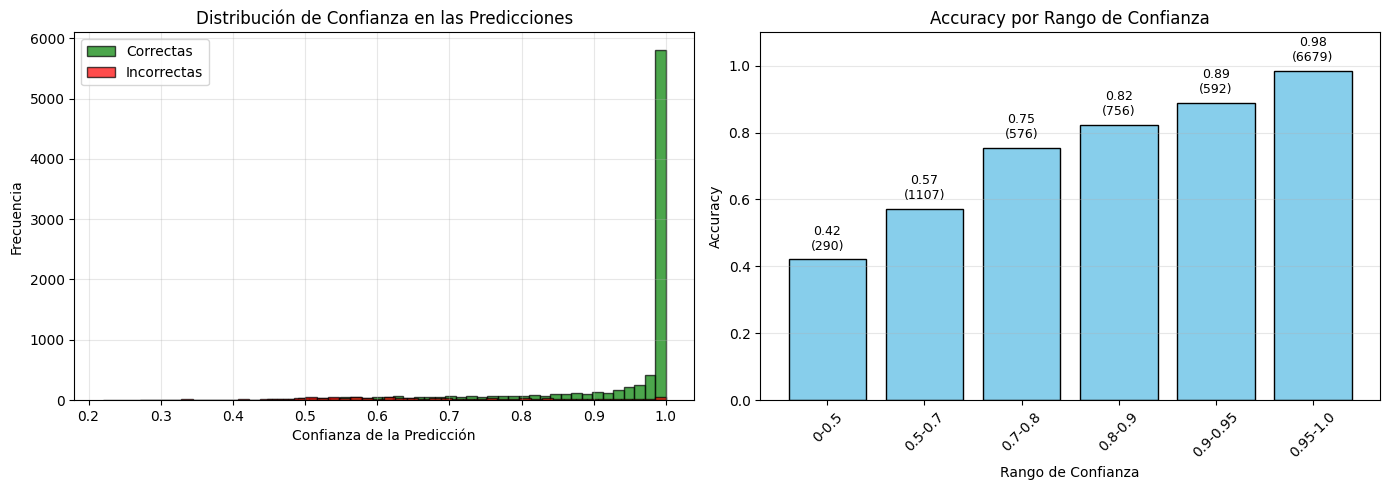


Predicciones con alta confianza (>0.9) pero incorrectas:
Total: 172


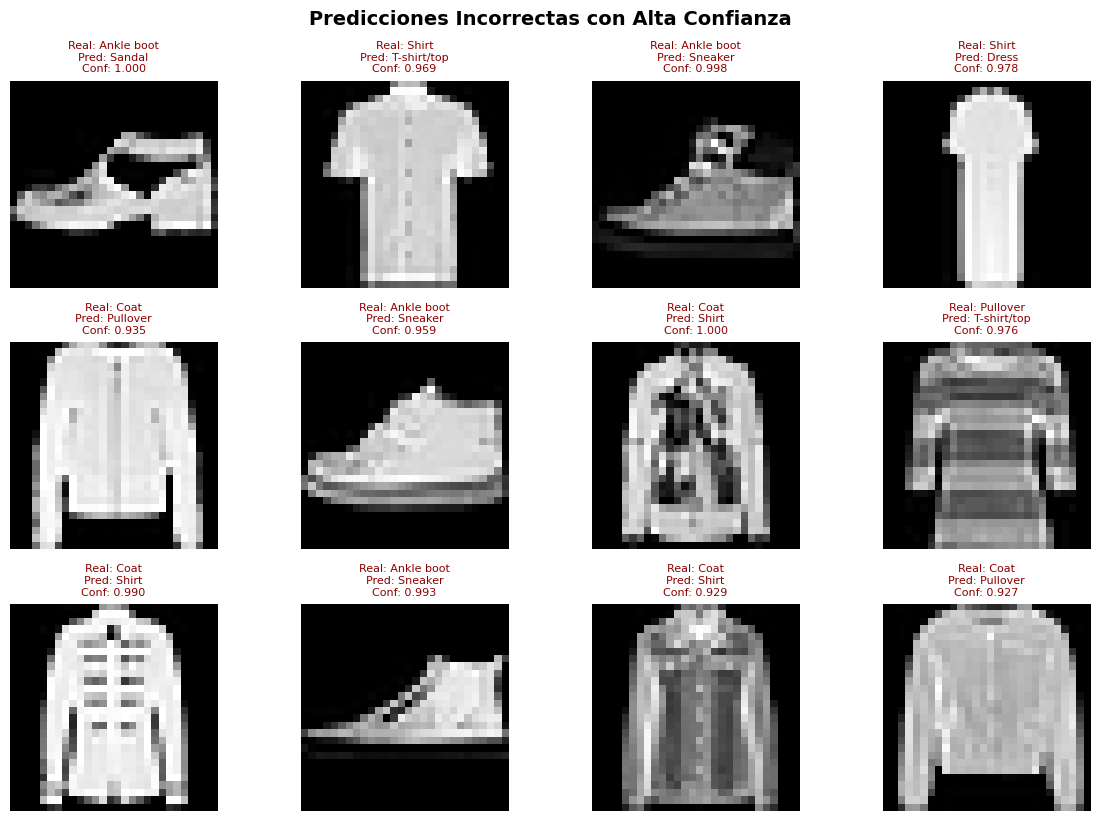

In [26]:
# Análisis de confianza de las predicciones
print("="*80)
print("ANÁLISIS DE CONFIANZA DE PREDICCIONES")
print("="*80 + "\n")

# Obtener probabilidades de predicción
probabilidades = model_6.predict(X_test_img, verbose=0)
confianzas = np.max(probabilidades, axis=1)
predicciones = np.argmax(probabilidades, axis=1)
correctas = predicciones == y_test

print(f"Confianza promedio: {confianzas.mean():.4f}")
print(f"Confianza promedio en predicciones correctas: {confianzas[correctas].mean():.4f}")
print(f"Confianza promedio en predicciones incorrectas: {confianzas[~correctas].mean():.4f}")

# Distribución de confianzas
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(confianzas[correctas], bins=50, alpha=0.7, label='Correctas', color='green', edgecolor='black')
plt.hist(confianzas[~correctas], bins=50, alpha=0.7, label='Incorrectas', color='red', edgecolor='black')
plt.xlabel('Confianza de la Predicción')
plt.ylabel('Frecuencia')
plt.title('Distribución de Confianza en las Predicciones')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
bins_conf = [0, 0.5, 0.7, 0.8, 0.9, 0.95, 1.0]
labels_conf = ['0-0.5', '0.5-0.7', '0.7-0.8', '0.8-0.9', '0.9-0.95', '0.95-1.0']

for i in range(len(bins_conf)-1):
    mask = (confianzas >= bins_conf[i]) & (confianzas < bins_conf[i+1])
    if i == len(bins_conf)-2:  # último bin incluye 1.0
        mask = (confianzas >= bins_conf[i]) & (confianzas <= bins_conf[i+1])
    
    total_bin = mask.sum()
    correctas_bin = (mask & correctas).sum()
    
    if total_bin > 0:
        acc_bin = correctas_bin / total_bin
        plt.bar(i, acc_bin, color='skyblue', edgecolor='black')
        plt.text(i, acc_bin + 0.02, f'{acc_bin:.2f}\n({total_bin})', 
                ha='center', va='bottom', fontsize=9)

plt.xlabel('Rango de Confianza')
plt.ylabel('Accuracy')
plt.title('Accuracy por Rango de Confianza')
plt.xticks(range(len(labels_conf)), labels_conf, rotation=45)
plt.ylim([0, 1.1])
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Mostrar predicciones con alta confianza pero incorrectas
print("\nPredicciones con alta confianza (>0.9) pero incorrectas:")
alta_confianza_incorrecta = np.where((confianzas > 0.9) & (~correctas))[0]
print(f"Total: {len(alta_confianza_incorrecta)}")

if len(alta_confianza_incorrecta) > 0:
    num_mostrar = min(12, len(alta_confianza_incorrecta))
    
    plt.figure(figsize=(12, 8))
    for i in range(num_mostrar):
        idx = alta_confianza_incorrecta[i]
        plt.subplot(3, 4, i + 1)
        plt.imshow(X_test[idx], cmap='gray')
        
        pred_class = predicciones[idx]
        real_class = y_test[idx]
        conf = confianzas[idx]
        
        plt.title(f'Real: {class_names[real_class]}\n'
                  f'Pred: {class_names[pred_class]}\n'
                  f'Conf: {conf:.3f}',
                  fontsize=8, color='darkred')
        plt.axis('off')
    
    plt.tight_layout()
    plt.suptitle('Predicciones Incorrectas con Alta Confianza', 
                 y=1.02, fontsize=14, fontweight='bold')
    plt.show()
else:
    print("No hay predicciones incorrectas con confianza > 0.9")

ANÁLISIS DE RENDIMIENTO POR CLASE

      Clase  Precisión  Recall  F1-Score  Muestras
T-shirt/top   0.870564   0.834  0.851890      1000
    Trouser   0.980847   0.973  0.976908      1000
   Pullover   0.788079   0.833  0.809917      1000
      Dress   0.885939   0.901  0.893406      1000
       Coat   0.806225   0.803  0.804609      1000
     Sandal   0.978831   0.971  0.974900      1000
      Shirt   0.728674   0.709  0.718702      1000
    Sneaker   0.940546   0.965  0.952616      1000
        Bag   0.968096   0.971  0.969546      1000
 Ankle boot   0.964503   0.951  0.957704      1000


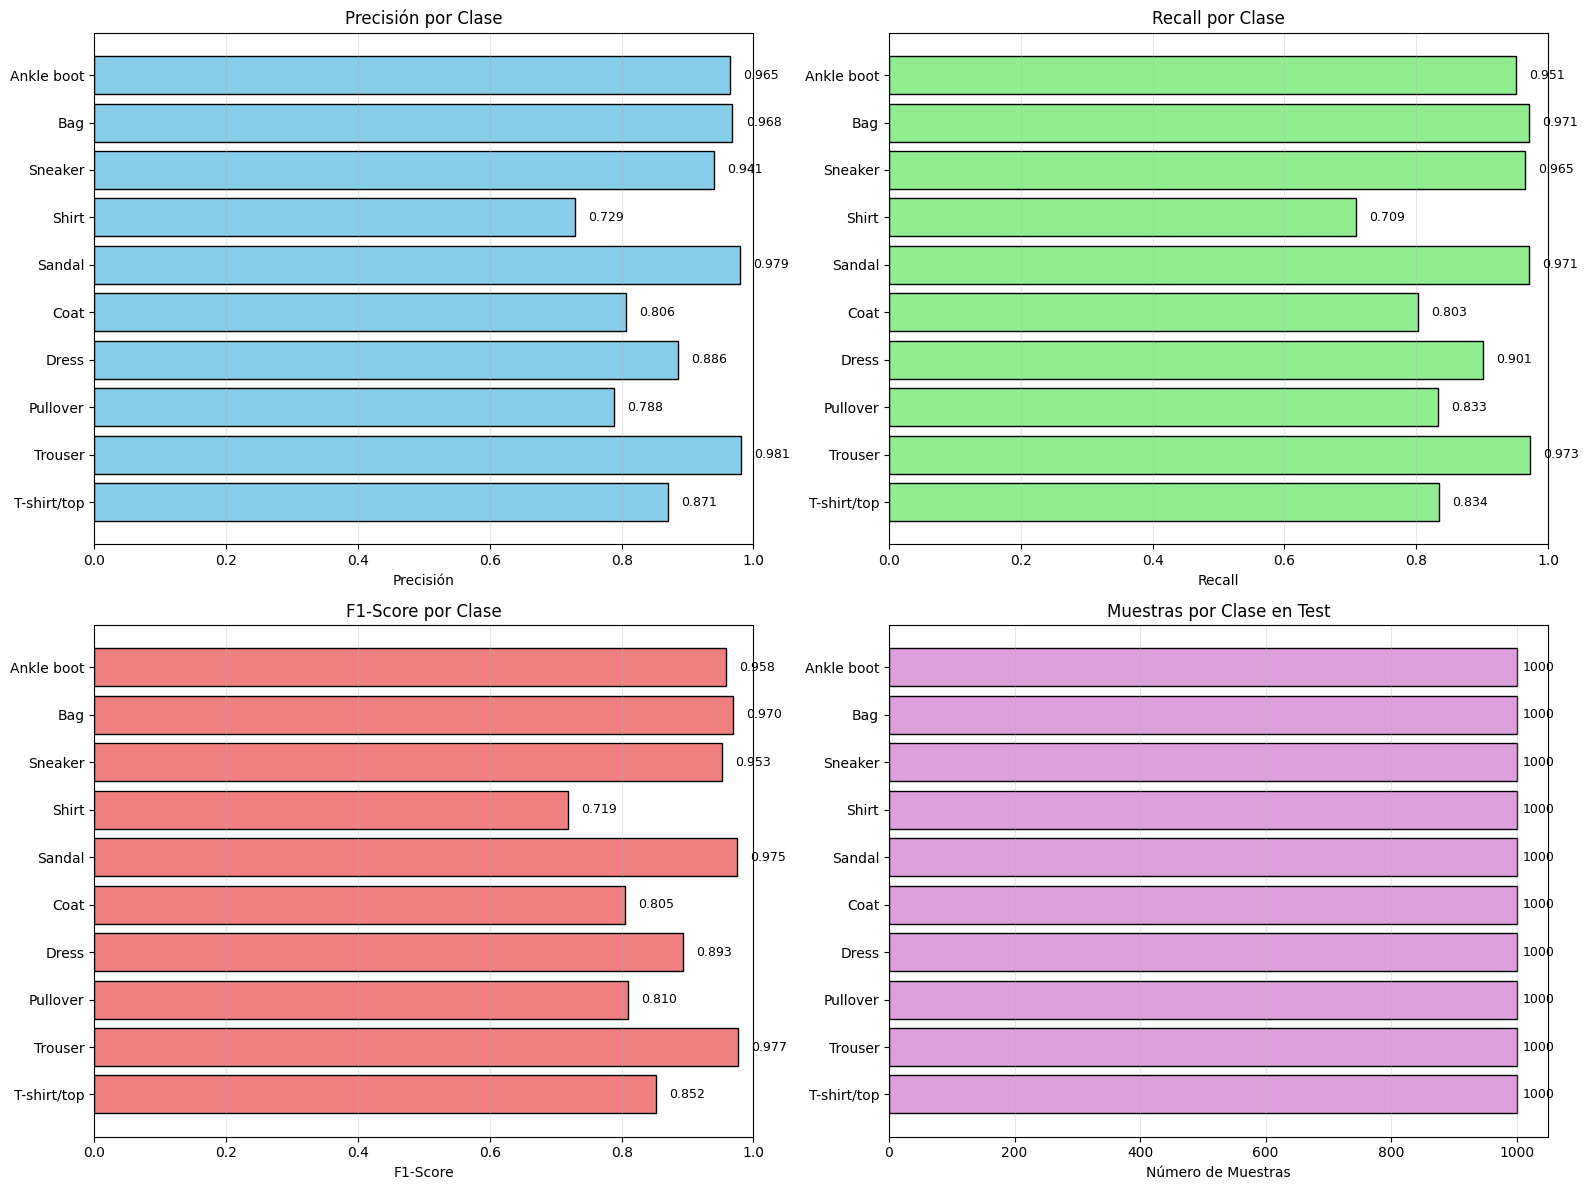


MEJOR CLASE: Trouser
  F1-Score: 0.9769
  Precisión: 0.9808
  Recall: 0.9730

PEOR CLASE: Shirt
  F1-Score: 0.7187
  Precisión: 0.7287
  Recall: 0.7090

Ejemplos de la clase más difícil (Shirt):


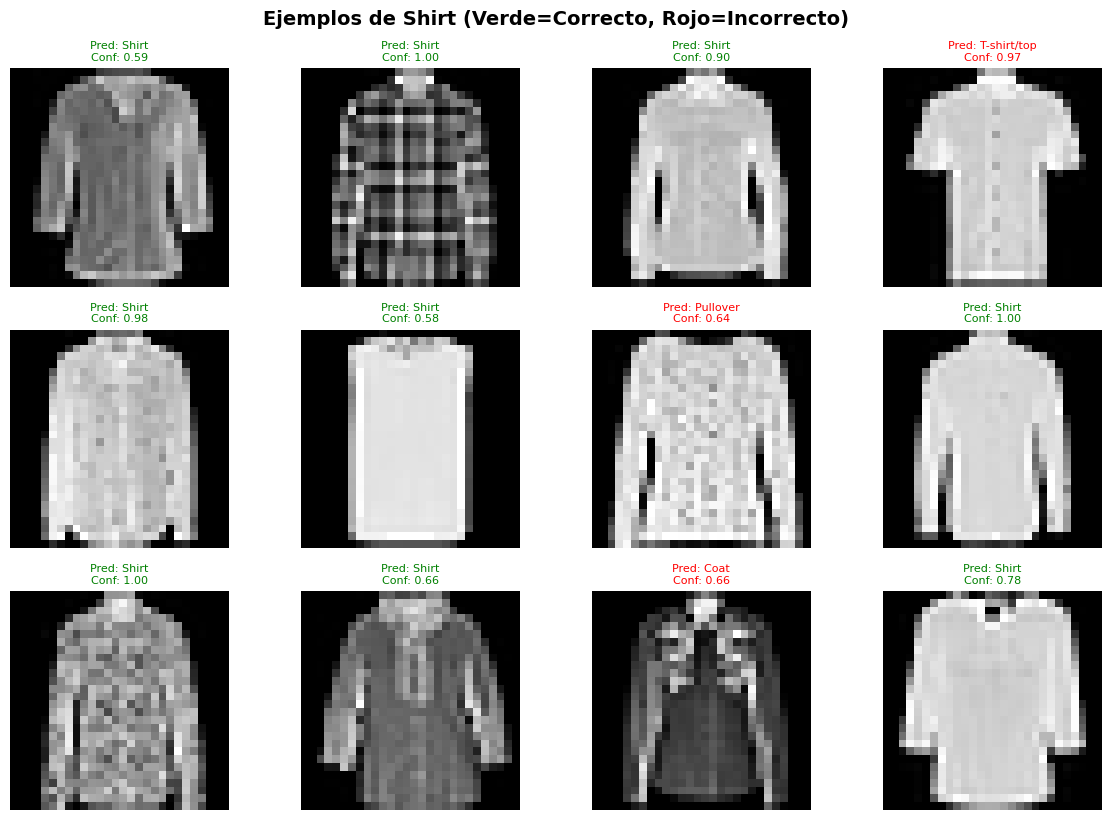

In [27]:
# Análisis de rendimiento por clase
print("="*80)
print("ANÁLISIS DE RENDIMIENTO POR CLASE")
print("="*80 + "\n")

# Calcular métricas por clase
from sklearn.metrics import precision_recall_fscore_support

precision_por_clase, recall_por_clase, f1_por_clase, support_por_clase = precision_recall_fscore_support(
    y_test, y_pred_classes_all, average=None, zero_division=0
)

# Crear DataFrame con las métricas
df_por_clase = pd.DataFrame({
    'Clase': class_names,
    'Precisión': precision_por_clase,
    'Recall': recall_por_clase,
    'F1-Score': f1_por_clase,
    'Muestras': support_por_clase
})

print(df_por_clase.to_string(index=False))

# Visualización de métricas por clase
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gráfico 1: Precisión por clase
axes[0, 0].barh(range(len(class_names)), precision_por_clase, color='skyblue', edgecolor='black')
axes[0, 0].set_yticks(range(len(class_names)))
axes[0, 0].set_yticklabels(class_names)
axes[0, 0].set_xlabel('Precisión')
axes[0, 0].set_title('Precisión por Clase')
axes[0, 0].set_xlim([0, 1])
axes[0, 0].grid(axis='x', alpha=0.3)
for i, v in enumerate(precision_por_clase):
    axes[0, 0].text(v + 0.02, i, f'{v:.3f}', va='center', fontsize=9)

# Gráfico 2: Recall por clase
axes[0, 1].barh(range(len(class_names)), recall_por_clase, color='lightgreen', edgecolor='black')
axes[0, 1].set_yticks(range(len(class_names)))
axes[0, 1].set_yticklabels(class_names)
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_title('Recall por Clase')
axes[0, 1].set_xlim([0, 1])
axes[0, 1].grid(axis='x', alpha=0.3)
for i, v in enumerate(recall_por_clase):
    axes[0, 1].text(v + 0.02, i, f'{v:.3f}', va='center', fontsize=9)

# Gráfico 3: F1-Score por clase
axes[1, 0].barh(range(len(class_names)), f1_por_clase, color='lightcoral', edgecolor='black')
axes[1, 0].set_yticks(range(len(class_names)))
axes[1, 0].set_yticklabels(class_names)
axes[1, 0].set_xlabel('F1-Score')
axes[1, 0].set_title('F1-Score por Clase')
axes[1, 0].set_xlim([0, 1])
axes[1, 0].grid(axis='x', alpha=0.3)
for i, v in enumerate(f1_por_clase):
    axes[1, 0].text(v + 0.02, i, f'{v:.3f}', va='center', fontsize=9)

# Gráfico 4: Número de muestras por clase
axes[1, 1].barh(range(len(class_names)), support_por_clase, color='plum', edgecolor='black')
axes[1, 1].set_yticks(range(len(class_names)))
axes[1, 1].set_yticklabels(class_names)
axes[1, 1].set_xlabel('Número de Muestras')
axes[1, 1].set_title('Muestras por Clase en Test')
axes[1, 1].grid(axis='x', alpha=0.3)
for i, v in enumerate(support_por_clase):
    axes[1, 1].text(v + 10, i, f'{v}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Identificar las mejores y peores clases
mejor_clase_idx = np.argmax(f1_por_clase)
peor_clase_idx = np.argmin(f1_por_clase)

print(f"\n{'='*80}")
print(f"MEJOR CLASE: {class_names[mejor_clase_idx]}")
print(f"  F1-Score: {f1_por_clase[mejor_clase_idx]:.4f}")
print(f"  Precisión: {precision_por_clase[mejor_clase_idx]:.4f}")
print(f"  Recall: {recall_por_clase[mejor_clase_idx]:.4f}")

print(f"\nPEOR CLASE: {class_names[peor_clase_idx]}")
print(f"  F1-Score: {f1_por_clase[peor_clase_idx]:.4f}")
print(f"  Precisión: {precision_por_clase[peor_clase_idx]:.4f}")
print(f"  Recall: {recall_por_clase[peor_clase_idx]:.4f}")
print(f"{'='*80}")

# Mostrar ejemplos de la clase más difícil
print(f"\nEjemplos de la clase más difícil ({class_names[peor_clase_idx]}):")
indices_peor_clase = np.where(y_test == peor_clase_idx)[0]

if len(indices_peor_clase) > 0:
    num_mostrar = min(12, len(indices_peor_clase))
    indices_mostrar = indices_peor_clase[:num_mostrar]
    
    plt.figure(figsize=(12, 8))
    for i in range(num_mostrar):
        idx = indices_mostrar[i]
        plt.subplot(3, 4, i + 1)
        plt.imshow(X_test[idx], cmap='gray')
        
        pred_class = y_pred_classes_all[idx]
        real_class = y_test[idx]
        conf = confianzas[idx]
        
        color = 'green' if pred_class == real_class else 'red'
        
        plt.title(f'Pred: {class_names[pred_class]}\n'
                  f'Conf: {conf:.2f}',
                  fontsize=8, color=color)
        plt.axis('off')
    
    plt.tight_layout()
    plt.suptitle(f'Ejemplos de {class_names[peor_clase_idx]} (Verde=Correcto, Rojo=Incorrecto)', 
                 y=1.02, fontsize=14, fontweight='bold')
    plt.show()

In [28]:
# Guardar el mejor modelo
print("="*80)
print("GUARDAR MODELO")
print("="*80 + "\n")

modelo_guardar = model_6  # o el mejor modelo según tu análisis
nombre_archivo = 'fashion_mnist_best_model.h5'

print(f"Guardando modelo en: {nombre_archivo}")
modelo_guardar.save(nombre_archivo)
print(f"✓ Modelo guardado exitosamente")

# También podemos guardar en formato SavedModel (recomendado)
nombre_carpeta = 'fashion_mnist_saved_model'
print(f"\nGuardando modelo en formato SavedModel: {nombre_carpeta}/")
modelo_guardar.export(nombre_carpeta)
print(f"✓ Modelo guardado exitosamente en formato SavedModel")

print("\n" + "="*80)
print("Para cargar el modelo posteriormente:")
print("="*80)
print("# Opción 1: Formato H5")
print("from keras.models import load_model")
print(f"modelo = load_model('{nombre_archivo}')")
print("\n# Opción 2: Formato SavedModel")
print(f"modelo = keras.models.load_model('{nombre_carpeta}')")
print("="*80)

GUARDAR MODELO

Guardando modelo en: fashion_mnist_best_model.h5
✓ Modelo guardado exitosamente

Guardando modelo en formato SavedModel: fashion_mnist_saved_model/
INFO:tensorflow:Assets written to: fashion_mnist_saved_model\assets


INFO:tensorflow:Assets written to: fashion_mnist_saved_model\assets


Saved artifact at 'fashion_mnist_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28), dtype=tf.float32, name='keras_tensor_51')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  1621138357712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1621138345808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1621138344272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1621138342928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1620577052304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1621138357520: TensorSpec(shape=(), dtype=tf.resource, name=None)
✓ Modelo guardado exitosamente en formato SavedModel

Para cargar el modelo posteriormente:
# Opción 1: Formato H5
from keras.models import load_model
modelo = load_model('fashion_mnist_best_model.h5')

# Opción 2: Formato SavedModel
modelo = keras.models.load_model('fashion_mnist_saved_model')


HACER PREDICCIONES CON EL MODELO

Haciendo predicciones...


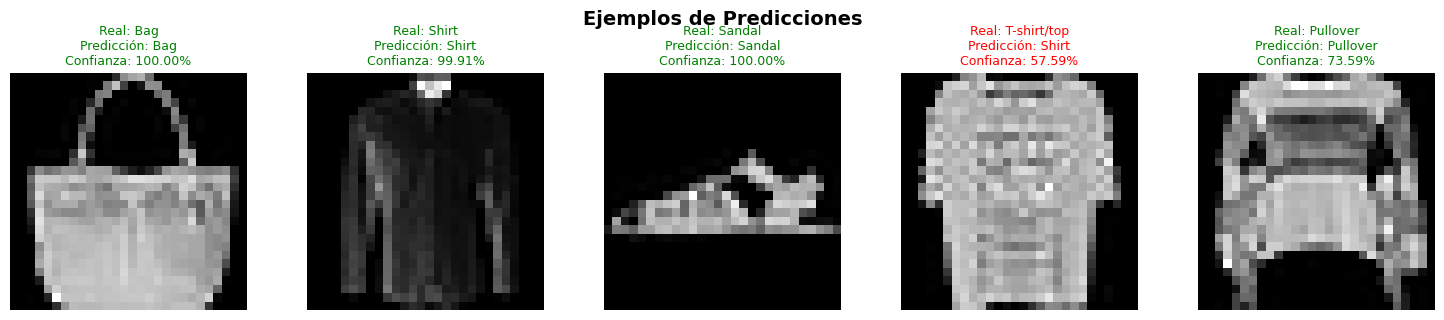


ANÁLISIS DETALLADO DE LA PRIMERA IMAGEN
Etiqueta real: Bag

Probabilidades para cada clase:
--------------------------------------------------
Bag             | ██████████████████████████████████████████████████ | 1.0000
T-shirt/top     |                                                    | 0.0000
Coat            |                                                    | 0.0000
Shirt           |                                                    | 0.0000
Pullover        |                                                    | 0.0000
Sneaker         |                                                    | 0.0000
Sandal          |                                                    | 0.0000
Dress           |                                                    | 0.0000
Ankle boot      |                                                    | 0.0000
Trouser         |                                                    | 0.0000

FUNCIÓN DE EJEMPLO PARA PREDICCIÓN

Ejemplo de uso de la función predecir_i

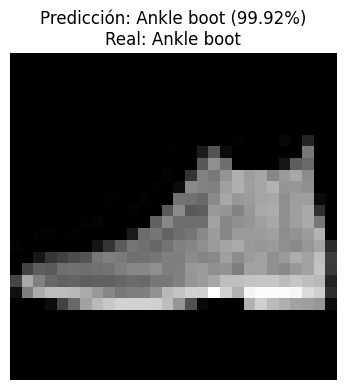

In [29]:
# Predicción con nuevas imágenes (simulación)
print("="*80)
print("HACER PREDICCIONES CON EL MODELO")
print("="*80 + "\n")

# Seleccionar 5 imágenes aleatorias del conjunto de test
indices_ejemplo = np.random.choice(len(X_test), 5, replace=False)
imagenes_ejemplo = X_test[indices_ejemplo]
etiquetas_reales = y_test[indices_ejemplo]

# Normalizar las imágenes
imagenes_normalizadas = imagenes_ejemplo / 255.0

# Hacer predicciones
print("Haciendo predicciones...")
predicciones_ejemplo = model_6.predict(imagenes_normalizadas, verbose=0)

# Mostrar resultados
plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(imagenes_ejemplo[i], cmap='gray')
    
    # Obtener la clase predicha y su probabilidad
    clase_predicha = np.argmax(predicciones_ejemplo[i])
    probabilidad = predicciones_ejemplo[i][clase_predicha]
    clase_real = etiquetas_reales[i]
    
    # Color basado en si es correcto o no
    color = 'green' if clase_predicha == clase_real else 'red'
    
    plt.title(f'Real: {class_names[clase_real]}\n'
              f'Predicción: {class_names[clase_predicha]}\n'
              f'Confianza: {probabilidad:.2%}',
              fontsize=9, color=color)
    plt.axis('off')

plt.tight_layout()
plt.suptitle('Ejemplos de Predicciones', y=1.05, fontsize=14, fontweight='bold')
plt.show()

# Mostrar las probabilidades detalladas para la primera imagen
print(f"\n{'='*80}")
print(f"ANÁLISIS DETALLADO DE LA PRIMERA IMAGEN")
print(f"{'='*80}")
print(f"Etiqueta real: {class_names[etiquetas_reales[0]]}")
print(f"\nProbabilidades para cada clase:")
print("-" * 50)

# Ordenar clases por probabilidad (de mayor a menor)
probs_ordenadas = np.argsort(predicciones_ejemplo[0])[::-1]

for idx in probs_ordenadas:
    prob = predicciones_ejemplo[0][idx]
    barra = '█' * int(prob * 50)
    print(f"{class_names[idx]:15s} | {barra:50s} | {prob:.4f}")

print(f"{'='*80}")

# Función de ejemplo para usar el modelo con una nueva imagen
print("\n" + "="*80)
print("FUNCIÓN DE EJEMPLO PARA PREDICCIÓN")
print("="*80)

def predecir_imagen(modelo, imagen):
    """
    Predice la clase de una imagen de Fashion MNIST.
    
    Parámetros:
    - modelo: modelo entrenado de Keras
    - imagen: array numpy de forma (28, 28) con valores 0-255
    
    Retorna:
    - clase_predicha: índice de la clase predicha
    - nombre_clase: nombre de la clase predicha
    - probabilidad: probabilidad de la predicción
    - todas_probabilidades: array con probabilidades de todas las clases
    """
    # Normalizar
    imagen_normalizada = imagen / 255.0
    
    # Añadir dimensión batch
    imagen_batch = np.expand_dims(imagen_normalizada, axis=0)
    
    # Predecir
    predicciones = modelo.predict(imagen_batch, verbose=0)
    
    # Obtener resultados
    clase_predicha = np.argmax(predicciones[0])
    probabilidad = predicciones[0][clase_predicha]
    nombre_clase = class_names[clase_predicha]
    
    return clase_predicha, nombre_clase, probabilidad, predicciones[0]

# Ejemplo de uso
print("\nEjemplo de uso de la función predecir_imagen:")
print("-" * 80)

imagen_prueba = X_test[0]
clase_idx, nombre, prob, todas_probs = predecir_imagen(model_6, imagen_prueba)

print(f"Clase predicha: {nombre} (índice: {clase_idx})")
print(f"Confianza: {prob:.2%}")
print(f"Clase real: {class_names[y_test[0]]}")

# Visualizar la imagen
plt.figure(figsize=(4, 4))
plt.imshow(imagen_prueba, cmap='gray')
plt.title(f'Predicción: {nombre} ({prob:.2%})\nReal: {class_names[y_test[0]]}', 
          fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.show()